In [1]:
(* This notebook illustrates the construction of several linear ID models from Radia's RK numerical trajectory computation and Elleaume's potential *)
(* The RK integrator is wrapped to model an ID as a thin nonlinear insertion in canonical variables *)
(* An interface to use the built-in WM ODE solver is provided for slope-based equations of motion and canonical equations with optional normalized external vector potentials *)
(* Elleaume's potential is updated for the case of different transverse field periodicity and also can be computed via build-in numerical integration *)
(* The Utilities section contains utility functions required to construct the linear ID model from Radia RK tracking or from Elleaume's potential or perform tracking *)
(* The linear transport matrix is computed using both approaches for a simple APPLE-II model adapted from Radia's examples *)

(* Ivan Morozov and Bruno Diviacco, 2025-2026 *)

In [8]:
(* The ID is modeled as a thin nonlinear insertion using the following steps: *)

(* 1. Given an initial condition in canonical coordinates at the ID center *)
(* 2. Propagate the initial condition to the ID entrance using an exact negative-drift propagator (near-zero-field location before the ID) *)
(* 3. Apply entrance angle correctors if any *)
(* 4. Convert canonical coordinates to slopes using zero-field-region relations *)
(* 5. Propagate to the ID exit using Radia's RK integrator or another slope-based integrator with a matching API *)
(* 6. Convert slopes to momenta using zero-field-region relations *)
(* 7. Apply exit angle correctors if any *)
(* 8. Propagate back to the ID center using an exact negative drift *)

(* These steps represent the effect of an ID as a thin nonlinear insertion *)
(* See the transport function for details *)

In [19]:
(* Linear ID model representation (thin-lens insertion at the magnet center) *)

(* (qx, px, qy, py) -> d(qx, px, qy, py)/d- dp + exp(S A) exp(S B -) (qx, px, qy, py) *)

(* S                        -- skew-symmetric symplectic identity matrix *)
(* dp                       -- energy/momentum deviation *)
(* d(qx, px, qy, py)/d-     -- energy-dependent reference orbit *)
(* exp(S A)                 -- on-energy transverse transport matrix (exponential form), Aij = Aji *)
(* exp(S B dp)              -- leading-order chromatic matrix, Bij = Bji *)

In [26]:
(* Linear ID model computation steps (Radia's RK) *)

(* 1. Given a thin nonlinear insertion mapping (black-box mapping zero to zero) *)
(* 2. Compute the energy-dependent reference orbit *)
(* 3. Compute the on-energy transport matrix using small deviations *)
(* 4. Perform transport matrix symplectification and factorization *)
(* 5. Compute the derivative of the transport matrix with respect to the energy deviation *)
(* 6. Compute the leading-order chromatic matrix *)

In [33]:
(* Linear ID model computation steps (Elleaume's potential) *)

(* 1. Given the Radia magnet model *)
(* 2. Define a single-kick (or one-kick-per-period) nonlinear thin insertion mapping *)
(* 3. Compute relevant quantities following the above Radia RK workflow (no reference-orbit correction or chromatic-orbit change for this case) *)

(* This can also be done using an interpolation table for the transverse momentum kicks *)
(* Refer to the corresponding section *)

In [39]:
(* Linear ID model (Elleaume's potential and semi-parametric transport matrix for all periods) *)

(* 1. Given the Radia magnet model *)
(* 2. Compute focusing and defocusing parameters from the potentials for one ID period *)
(* 3. Use a (semi-)parametric ID transport matrix to compute the transport matrix and chromatic effects *)

In [43]:
(* Set library path *)

(* Example *)
(* > export WOLFLIB=/home/morozov/SOFT/WolframEngine/SystemFiles/Libraries/Linux-x86-64 *)
(* > export LD_LIBRARY_PATH="$WOLFLIB:$LD_LIBRARY_PATH" *)

wolflib = Environment["WOLFLIB"] ;
current = Environment["LD_LIBRARY_PATH"] ;
SetEnvironment["LD_LIBRARY_PATH" -> wolflib <> ":" <> current] ;

In [50]:
(* Load Radia *)

<< Radia` ; 

Radia Version: 4.32 is loaded
Radia is copyright ESRF, France.
Portions copyright Synchrotron SOLEIL, France.
Portions copyright Wolfram Research, Inc.


In [52]:
(* Load utility functions (or execute Utilities section) *)

<< matrix` ;

# Utilities

In [54]:
(* Transport matrix computation *)
(* I.M., 2025-2026 *)

(* --------- RadFldPtcTrj --------- *)

ClearAll[RadFldPtcTrj] ;
Options[RadFldPtcTrj] = {
	Method -> {"FixedStep", Method -> {"StiffnessSwitching", Method -> {"ExplicitRungeKutta", Automatic}}}
} ;
RadFldPtcTrj::usage="RadFldPtcTrj[obj, E, {x0, dxdy0, z0, dzdy0}, {y0, y1}, np] -- compute transverse coordinates and its derivatives (angles/slopes) of a relativistic charged particle trajectory in 3D magnetic field produced by the object obj, using the NDSolve interface (see default method options). The particle energy is E [GeV], initial transverse coordinates and derivatives are {x0, dxdy0, z0, dzdy0}; the longitudinal coordinate y is varied from y0 to y1 in np steps. All positions are in millimeters and angles in radians." ;
RadFldPtcTrj[obj_, E_, {x0_, dxdy0_, z0_, dzdy0_}, {y0_, y1_}, np_, options:OptionsPattern[]] := Block[
	{alpha, bx, by, bz, system, x, xp, z, zp, xi, xpi, zi, zpi, y, solver, table, functions, positions},
	alpha = (0.299792458/E)/1000.0 ;
	bx[x_?NumericQ, y_?NumericQ, z_?NumericQ] := bx[x, y, z] = radFld[obj, "bx", {x, y, z}] ;
	by[x_?NumericQ, y_?NumericQ, z_?NumericQ] := by[x, y, z] = radFld[obj, "by", {x, y, z}] ;
	bz[x_?NumericQ, y_?NumericQ, z_?NumericQ] := bz[x, y, z] = radFld[obj, "bz", {x, y, z}] ;
	system = {
		x'[y] == xp[y],
		z'[y] == zp[y],
		xp'[y] == -alpha/Sqrt[1 + xp[y]^2 + zp[y]^2]*(zp[y]*by[x[y], y, z[y]] + (1 + xp[y]^2)*bz[x[y], y, z[y]] + xp[y]*zp[y]*bx[x[y], y, z[y]]),
		zp'[y] == +alpha/Sqrt[1 + xp[y]^2 + zp[y]^2]*(xp[y]*by[x[y], y, z[y]] + (1 + zp[y]^2)*bx[x[y], y, z[y]] + xp[y]*zp[y]*bz[x[y], y, z[y]]),
		x[y0] == xi,
		xp[y0] == xpi,
		z[y0] == zi,
		zp[y0] == zpi
	} ;
	solver = ParametricNDSolveValue[
		system,
		{x, xp, z, zp},
		{y, y0, y1},
		{xi, xpi, zi, zpi},
		Method -> OptionValue[Method],
		StartingStepSize -> (y1 - y0)/np,
		MaxStepSize  -> (y1 - y0)/np
	] ;
	functions = solver[x0, dxdy0, z0, dzdy0] ;
	positions = Subdivide[y0, y1, np - 1] ;
	Map[Flatten, Transpose[{positions, Map[Function[{position}, Through[functions[position]]], positions]}]]
] ;

(* --------- RadFldPtcTrjCnn --------- *)

ClearAll[RadFldPtcTrjCnn];
Options[RadFldPtcTrjCnn] = {
	"Delta" -> {0.1, 0.1},
	Method -> {"FixedStep", Method -> {"StiffnessSwitching", Method -> {"ExplicitRungeKutta", Automatic}}}
} ;
RadFldPtcTrjCnn::usage="RadFldPtcTrjCnn[obj, E, dE, {qx0, px0, qz0, pz0}, {y0, y1}, np, {extAx, extAy, extAz}] -- compute transverse canonical coordinates of a relativistic charged particle trajectory in 3D magnetic field produced by the object obj, using the NDSolve interface (see default options). The particle energy is E [GeV], initial transverse canonical coordinates are {qx0, px0, qz0, pz0}; the longitudinal coordinate y is varied from y0 to y1 in np steps. All positions are in millimeters." ;
RadFldPtcTrjCnn[obj_, E_, dE_, {qx0_, px0_, qz0_, pz0_}, {y0_, y1_}, np_, {extAx_, extAy_, extAz_}, options : OptionsPattern[]] := Block[
	{alpha, Ax, Ay, Az, ax, ay, az, daxdx, daydx, dazdx, daxdz, daydz, dazdz, hx, hz, flow, system, y, qx, qz, px, pz, qxi, qzi, pxi, pzi, solver, functions, positions},
	alpha = -(0.299792458/E)/1000.0 ;
	Ax[x_?NumericQ, y_?NumericQ, z_?NumericQ] := Ax[x, y, z] = radFld[obj, "ax", {x, y, z}] ;
	Ay[x_?NumericQ, y_?NumericQ, z_?NumericQ] := Ay[x, y, z] = radFld[obj, "ay", {x, y, z}] ;
	Az[x_?NumericQ, y_?NumericQ, z_?NumericQ] := Az[x, y, z] = radFld[obj, "az", {x, y, z}] ;
	ax[x_?NumericQ, y_?NumericQ, z_?NumericQ] := alpha*Ax[x, y, z] + extAx[x, y, z] ;
	ay[x_?NumericQ, y_?NumericQ, z_?NumericQ] := alpha*Ay[x, y, z] + extAy[x, y, z] ;
	az[x_?NumericQ, y_?NumericQ, z_?NumericQ] := alpha*Az[x, y, z] + extAz[x, y, z] ;
	daxdx[x_?NumericQ, y_?NumericQ, z_?NumericQ] := daxdx[x, y, z] = (ax[x + hx, y, z] - ax[x - hx, y, z])/(2 hx) ;
	daydx[x_?NumericQ, y_?NumericQ, z_?NumericQ] := daydx[x, y, z] = (ay[x + hx, y, z] - ay[x - hx, y, z])/(2 hx) ;
	dazdx[x_?NumericQ, y_?NumericQ, z_?NumericQ] := dazdx[x, y, z] = (az[x + hx, y, z] - az[x - hx, y, z])/(2 hx) ;
	daxdz[x_?NumericQ, y_?NumericQ, z_?NumericQ] := daxdz[x, y, z] = (ax[x, y, z + hz] - ax[x, y, z - hz])/(2 hz) ;
	daydz[x_?NumericQ, y_?NumericQ, z_?NumericQ] := daydz[x, y, z] = (ay[x, y, z + hz] - ay[x, y, z - hz])/(2 hz) ;
	dazdz[x_?NumericQ, y_?NumericQ, z_?NumericQ] := dazdz[x, y, z] = (az[x, y, z + hz] - az[x, y, z - hz])/(2 hz) ;
	{hx, hz} = OptionValue["Delta"] ;
	flow[qx_, qz_, px_, pz_, y_] := flow[qx, qz, px, pz, y] = Block[
		{axi, ayi, azi, pix, piz, sqrt, daxdxi, daydxi, dazdxi, daxdzi, daydzi, dazdzi, qxdot, qzdot, pxdot, pzdot},
		axi = ax[qx, y, qz] ;
		ayi = ay[qx, y, qz] ;
		azi = az[qx, y, qz] ;
		pix = px - axi ;
		piz = pz - azi ;
		sqrt = Sqrt[(1 + dE)^2 - pix^2 - piz^2] ;
		daxdxi = daxdx[qx, y, qz] ;
		daydxi = daydx[qx, y, qz] ;
		dazdxi = dazdx[qx, y, qz] ;
		daxdzi = daxdz[qx, y, qz] ;
		daydzi = daydz[qx, y, qz] ;
		dazdzi = dazdz[qx, y, qz] ;
		qxdot = pix/sqrt ;
		qzdot = piz/sqrt ;
		pxdot = daydxi + (pix*daxdxi + piz*dazdxi)/sqrt ;
		pzdot = daydzi + (pix*daxdzi + piz*dazdzi)/sqrt ;
		{qxdot, qzdot, pxdot, pzdot}
	] ;
	system = {
		{qx'[y], qz'[y], px'[y], pz'[y]} == flow[qx[y], qz[y], px[y], pz[y], y],
		qx[y0] == qxi,
		px[y0] == pxi,
		qz[y0] == qzi,
		pz[y0] == pzi
	} ;
	solver = ParametricNDSolveValue[
		system,
		{qx, px, qz, pz},
		{y, y0, y1},
		{qxi, pxi, qzi, pzi},
		Method -> OptionValue[Method],
		StartingStepSize -> (y1 - y0)/np,
		MaxStepSize -> (y1 - y0)/np
	] ;
	functions = solver[qx0, px0, qz0, pz0] ;
	positions = Subdivide[y0, y1, np - 1] ;
	Map[Flatten, Transpose[{positions, Map[Function[{position}, Through[functions[position]]], positions]}]]
] ;

(* --------- transport --------- *)

ClearAll[transport] ;
Options[transport] = {
	Method -> {"FixedStep", Method -> {"StiffnessSwitching", Method -> {"ExplicitRungeKutta", Automatic}}},
	"Thin" -> True
} ;
transport::usage = "transport[object, energy, delta, {start, stop}, steps, angles, solver][{qx, px, qz, pz}] -- track canonical initial condition (qx, px, qz, pz) with (qx, qz in m) through slope-based solver (x and z in mm)" ;
transport[
	object_,                  (* -- magnet object *)
	energy_,                  (* -- reference energy (GeV) *)
	delta_,                   (* -- energy deviation *)
	{start_, stop_},          (* -- integration start and stop positions relative to the object *)
	steps_,                   (* -- number of integration steps *)
	angles_:{0, 0, 0, 0},     (* -- angle kicks to be added to canonical momenta on entrance and exit (cxi, czi, cxf, czf) *)
	solver_:radFldPtcTrj,     (* -- solver (radFldPtcTrj or RadFldPtcTrj) *)
	options:OptionsPattern[]  (* -- options *)
][state_] := Block[
	{QX, PX, QZ, PZ, X, XP, Z, ZP, CXI, CZI, CXF, CZF},
	{QX, PX, QZ, PZ} = state ;
	{CXI, CZI, CXF, CZF} = angles ;
	If[
		OptionValue["Thin"],
		{QX, PX, QZ, PZ} = {QX - 1/2*(stop - start)/1000.0*PX/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PX, QZ - 1/2*(stop - start)/1000.0*PZ/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PZ} ;
	] ;
	{QX, PX, QZ, PZ} = {QX, PX + CXI, QZ, PZ + CZI} ;
    {X, XP, Z, ZP} = {QX, PX/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], QZ, PZ/Sqrt[(1 + delta)^2 - PX^2 - PZ^2]} ;
    {X, XP, Z, ZP} = {1000.0*X, XP, 1000.0*Z, ZP} ;
    {X, XP, Z, ZP} = Rest[Last[solver[object, energy*(1 + delta), {X, XP, Z, ZP}, {start, stop}, steps, Sequence @@ FilterRules[options, Options[NDSolve]]]]] ;
    {X, XP, Z, ZP} = {X/1000.0, XP, Z/1000.0, ZP} ;
    {QX, PX, QZ, PZ} = {X, (1 + delta)*XP/Sqrt[1 + XP^2 + ZP^2], Z, (1 + delta)*ZP/Sqrt[1 + XP^2 + ZP^2]} ;
    {QX, PX, QZ, PZ} = {QX, PX + CXF, QZ, PZ + CZF} ;
	If[
		OptionValue["Thin"],
		{QX, PX, QZ, PZ} = {QX - 1/2*(stop - start)/1000.0*PX/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PX, QZ - 1/2*(stop - start)/1000.0*PZ/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PZ} ;
	] ;
    {QX, PX, QZ, PZ}
] ;

(* --------- amplitude --------- *)

ClearAll[amplitude] ;
Options[amplitude] = {"SamplesPerHarmonic" -> 32, "Samples" -> Automatic} ;
amplitude::usage = "amplitude[object, component, period, reference, harmonic, options] -- compute the amplitude of the n-th fourier harmonic of given periodic field component over one longitudinal period centered at given reference point using trapezoidal rule " ;
amplitude[                    (* -- amplitude *)
    object_,                  (* -- radia object *)
    component_,               (* -- field component *)
    period_,                  (* -- longitudinal period (mm) *)
    reference_,               (* -- reference point (mm) *)
    harmonic_,                (* -- harmonic number *)
    options:OptionsPattern[]  (* -- options *)
] := Block[
    {count, fields, weights, range, angles, cos, sin},
    count = If[OptionValue["Samples"] === Automatic, harmonic*OptionValue["SamplesPerHarmonic"], OptionValue["Samples"]] ;
    fields = radFldLst[object, component, reference - {0, period/2, 0}, reference + {0, period/2, 0}, count] ;
    weights = ConstantArray[1.0, count] ;
    weights[[+1]] = 0.5 ;
    weights[[-1]] = 0.5 ;
    range = Range[0, count - 1] ;
    angles = 2*Pi*harmonic*range/(count - 1) ;
    cos = (2/(count - 1))*Total[weights*fields*Cos[angles]] ;
    sin = (2/(count - 1))*Total[weights*fields*Sin[angles]] ;
    Sqrt[cos^2 + sin^2]
] ;

(* --------- Elleaume potential (periodic field) --------- *)

ClearAll[potential] ;
Options[potential] = Join[{"SamplesPerHarmonic" -> 32, "Samples" -> Automatic, NIntegrate -> False}, Options[NIntegrate]] ;
potential::usage = "potential[object, {x, z}, periods, harmonics, shift, options] -- compute Elleaume one-(super)period potential. By default sampled Fourier amplitudes are used; use NIntegrate -> True to compute the full period integral directly from shift - period/2 to shift + period/2 without harmonic expansion." ;
potential[                    (* -- potential (T^2 mm^3) *)
    object_,                  (* -- radia object *)
    {x_, z_},                 (* -- transverse evaluation point (mm) *)
    periods_,                 (* -- horizontal and vertical periods (mm), {ph, pv} = {n*p, p} or {p, n*p} and n*p -- super-period *)
    harmonics_,               (* -- list of harmonics *)
    shift_,                   (* -- longitudinal shift/position (mm) *)
    options:OptionsPattern[]  (* -- options *)
] := Block[{period, hx, hz, start, stop, integrate, field, primitive, value, bx, bz},
  period = Max[periods] ;
  {hx, hz} = Round[period/periods] ;
  If[
    OptionValue[NIntegrate],
    start = shift - period/2 ;
    stop = shift + period/2 ;
    integrate[integrand_, range_] := Apply[NIntegrate, Join[{integrand, range}, FilterRules[{options}, Options[NIntegrate]]]] ;
    field[component_, y_?NumericQ] := field[component, y] = radFld[object, component, {x, y, z}] ;
    primitive[component_, y_?NumericQ] := primitive[component, y] = integrate[field[component, s], {s, start, y}] ;
    value[component_] := value[component] = integrate[primitive[component, y], {y, start, stop}]/period ;
    integrate[(primitive["bx", y] - value["bx"])^2 + (primitive["bz", y] - value["bz"])^2, {y, start, stop}],
    bx = Table[amplitude[object, "bx", period, {x, shift, z}, hx*harmonic, Sequence @@ FilterRules[{options}, Options[amplitude]]], {harmonic, harmonics}] ;
    bz = Table[amplitude[object, "bz", period, {x, shift, z}, hz*harmonic, Sequence @@ FilterRules[{options}, Options[amplitude]]], {harmonic, harmonics}] ;
    0.5*period*(period/(2*Pi))^2*Total[(bx^2/hx^2 + bz^2/hz^2)/harmonics^2]
  ]
] ;

(* --------- horizontal slope kick (period) --------- *)

ClearAll[dxp] ;
Options[potential] = Join[{"SamplesPerHarmonic" -> 32, "Samples" -> Automatic, NIntegrate -> False}, Options[NIntegrate]] ;
dxp::usage = "dxp[object, {x, z}, periods, harmonics, shift, energy, delta, options] -- compute one-(super) period horizontal angle kick (murad) using central finite difference" ;
dxp[                          (* -- one-(super) period horizontal angle kick (murad) *)
    object_,                  (* -- radia object *)
    {x_, z_},                 (* -- transverse evaluation point (mm) *)
    periods_,                 (* -- horizontal and vertical periods (mm), {ph, pv} = {n*p, p} or {p, n*p} and n*p -- super-period *)
    harmonics_,               (* -- list of harmonics *)
    shift_,                   (* -- longitudinal shift/position (mm) *)
    energy_,                  (* -- reference energy (GeV) *)
    delta_,                   (* -- finite difference delta (mm) *)
    options:OptionsPattern[]  (* -- options *)
] := Block[{pa, pb},
    pa = potential[object, {x - delta/2, z}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    pb = potential[object, {x + delta/2, z}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    (pb - pa)/delta*0.5*(0.299792458/energy)^2
] ;

(* --------- vertical slope kick (period) --------- *)

ClearAll[dzp] ;
Options[potential] = Join[{"SamplesPerHarmonic" -> 32, "Samples" -> Automatic, NIntegrate -> False}, Options[NIntegrate]] ;
dzp::usage = "dzp[object, {x, z}, periods, harmonics, shift, energy, delta, options] -- compute one-(super) period vertical angle kick (murad) using central finite difference" ;
dzp[                          (* -- one-(super) period vertical angle kick (murad) *)
    object_,                  (* -- radia object *)
    {x_, z_},                 (* -- transverse evaluation point (mm) *)
    periods_,                 (* -- horizontal and vertical periods (mm), {ph, pv} = {n*p, p} or {p, n*p} and n*p -- super-period *)
    harmonics_,               (* -- list of harmonics *)
    shift_,                   (* -- longitudinal shift/position (mm) *)
    energy_,                  (* -- reference energy (GeV) *)
    delta_,                   (* -- finite difference delta (mm) *)
    options:OptionsPattern[]  (* -- options *)
] := Block[{pa, pb},
    pa = potential[object, {x, z - delta/2}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    pb = potential[object, {x, z + delta/2}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    (pb - pa)/delta*0.5*(0.299792458/energy)^2
] ;

(* --------- horizontal focusing strength (period) --------- *)

ClearAll[kx] ;
Options[potential] = Join[{"SamplesPerHarmonic" -> 32, "Samples" -> Automatic, NIntegrate -> False}, Options[NIntegrate]] ;
kx::usage = "kx[object, {x, z}, periods, harmonics, shift, energy, delta, options] -- compute horizontal focusing strength using central finite difference" ;
kx[                           (* -- horizontal focusing strength (1/m) *)
    object_,                  (* -- radia object *)
    {x_, z_},                 (* -- transverse evaluation point (mm) *)
    periods_,                 (* -- horizontal and vertical periods (mm), {ph, pv} = {n*p, p} or {p, n*p} and n*p -- super-period *)
    harmonics_,               (* -- list of harmonics *)
    shift_,                   (* -- longitudinal shift/position (mm) *)
    energy_,                  (* -- reference energy (GeV) *)
    delta_,                   (* -- finite difference delta (mm) *)
    options:OptionsPattern[]  (* -- options *)
] := Block[{pa, pb, pc},
    pa = potential[object, {x - delta/2, z}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    pb = potential[object, {x, z}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    pc = potential[object, {x + delta/2, z}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    10.0^-3*4*(pa - 2*pb + pc)/delta^2*0.5*(0.299792458/energy)^2
] ;

(* --------- vertical focusing strength (period) --------- *)

ClearAll[kz] ;
Options[potential] = Join[{"SamplesPerHarmonic" -> 32, "Samples" -> Automatic, NIntegrate -> False}, Options[NIntegrate]] ;
kz::usage = "kz[object, {x, z}, periods, harmonics, shift, energy, delta, options] -- compute vertical focusing strength using central finite difference" ;
kz[                           (* -- vertical focusing strength (1/m) *)
    object_,                  (* -- radia object *)
    {x_, z_},                 (* -- transverse evaluation point (mm) *)
    periods_,                 (* -- horizontal and vertical periods (mm), {ph, pv} = {n*p, p} or {p, n*p} and n*p -- super-period *)
    harmonics_,               (* -- list of harmonics *)
    shift_,                   (* -- longitudinal shift/position (mm) *)
    energy_,                  (* -- reference energy (GeV) *)
    delta_,                   (* -- finite difference delta (mm) *)
    options:OptionsPattern[]  (* -- options *)
] := Block[{pa, pb, pc},
    pa = potential[object, {x, z - delta/2}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    pb = potential[object, {x, z}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    pc = potential[object, {x, z + delta/2}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    10.0^-3*4*(pa - 2*pb + pc)/delta^2*0.5*(0.299792458/energy)^2
] ;

(* --------- dkd potential based tracking --------- *)

ClearAll[dkd] ;
Options[potential] = Join[{"SamplesPerHarmonic" -> 32, "Samples" -> Automatic, NIntegrate -> False}, Options[NIntegrate]] ;
dkd::usage = "dkd[object, energy, delta, periods, harmonics, shift, step, count, factors, options][{qx, px, qz, pz}] -- drift-kick-drift canonical tracking (period in mm, x and z in m)" ;
dkd[                          (* -- drift-kick-drift canonical tracking *)
	object_,                  (* -- radia object *)
	energy_,                  (* -- reference energy (GeV) *)
	delta_,                   (* -- energy delta *)
	periods_,                 (* -- horizontal and vertical periods (mm), {ph, pv} = {n*p, p} or {p, n*p} and n*p -- super-period *)
	harmonics_,               (* -- list of harmonics *)
	shift_,                   (* -- longitudinal shift/position (mm) *)
	step_,                    (* -- finite difference delta (mm) *)
	count_,                   (* -- total number of (super) periods *)
	factors_:{1.0, 1.0},      (* -- extra kick multiplication factors *)
    options:OptionsPattern[]  (* -- options *)
][state_] := Block[
    {FX, FZ, QX, PX, QZ, PZ, X, XP, Z, ZP, DL},
    {FX, FZ} = factors ;
    {QX, PX, QZ, PZ} = state ;
    DL = Max[periods]/2/10.0^3 ;
    {QX, PX, QZ, PZ} = {QX - count*DL*PX/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PX, QZ - count*DL*PZ/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PZ} ;
    Do[
		{QX, PX, QZ, PZ} = {QX + DL*PX/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PX, QZ + DL*PZ/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PZ} ;
		{X, XP, Z, ZP} = {QX, PX/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], QZ, PZ/Sqrt[(1 + delta)^2 - PX^2 - PZ^2]} ;
		{X, XP, Z, ZP} = {
			X,
			XP - FX*dxp[object, 10.0^3*{X, Z}, periods, harmonics, shift, energy*(1 + delta), step, Sequence @@ FilterRules[{options}, Options[potential]]]*10^-6,
			Z,
			ZP - FZ*dzp[object, 10.0^3*{X, Z}, periods, harmonics, shift, energy*(1 + delta), step, Sequence @@ FilterRules[{options}, Options[potential]]]*10^-6
		} ;
		{QX, PX, QZ, PZ} = {X, (1 + delta)*XP/Sqrt[1 + XP^2 + ZP^2], Z, (1 + delta)*ZP/Sqrt[1 + XP^2 + ZP^2]} ;
		{QX, PX, QZ, PZ} = {QX + DL*PX/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PX, QZ + DL*PZ/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PZ},
		count
	] ;
    {QX, PX, QZ, PZ} = {QX - count*DL*PX/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PX, QZ - count*DL*PZ/Sqrt[(1 + delta)^2 - PX^2 - PZ^2], PZ} ;
	{QX, PX, QZ, PZ}
] ;

(* --------- explicit ID transport matrix (approximate) --------- *)

ClearAll[idtm] ;
idtm::usage = "idtm[{kx, kz}, {np, lp}, dp] -- compute id thin insertion exponent diagonal and corresponding transport matrix (second order in kx and kz)" ;
idtm[                         (* -- id thin insertion diagonal and transport matrix *)
	{kx_, kz_},               (* -- focusing strength (1/m) *)
	count_,                   (* -- total number of (super) periods *)
	period_,                  (* -- (super) period length (m) *)
	delta_                    (* -- energy delta *)
] := Block[
	{a, b, c, d, diagonal, matrix},
	a = (kx*count)/(1 + delta) - (kx^2*period*count*(-1 + count^2))/(6*(1 + delta)^3) ;
	b = (kx*period^2*count*(-1 + count^2))/(12*(1 + delta)^3) + (kx^2*period^3*count*(-1 + count^4))/(120*(1 + delta)^5) ;
	c = (kz*count)/(1 + delta) - (kz^2*period*count*(-1 + count^2))/(6*(1 + delta)^3); 
	d = (kz*period^2*count*(-1 + count^2))/(12*(1 + delta)^3) + (kz^2*period^3*count*(-1 + count^4))/(120*(1 + delta)^5) ;
	diagonal = {a, b, c, d} ;
	matrix = MatrixExp[{{0, 1, 0, 0}, {-1, 0, 0, 0}, {0, 0, 0, 1}, {0, 0, -1, 0}} . DiagonalMatrix[diagonal]] ;
	{diagonal, matrix}   
] ;

(* --------- symplectic identity matrix --------- *)

ClearAll[identity] ;
identity[dimension_] := KroneckerProduct[IdentityMatrix[dimension], {{0, 1}, {-1, 0}}] ;

(* --------- symplectify --------- *)

ClearAll[symplectify] ;
symplectify::usage = "symplectify[matrix] -- symplectify given matrix (symplectic projection)" ;
symplectify[matrix_] := Block[
  {size, dimension, E, S, V, W},
  size = Length[matrix] ;
  dimension = 1/2*size ;
  E = IdentityMatrix[size] ;
  S = identity[dimension] ;
  V = S.(E - matrix).LinearSolve[E + matrix, E] ;
  W = 1/2*(V + Transpose[V]) ;
  LinearSolve[S + W, S - W]
] ;

(* --------- transport matrix --------- *)

ClearAll[matrix] ;
Options[matrix] = {
	Method -> {"FixedStep", Method -> {"StiffnessSwitching", Method -> {"ExplicitRungeKutta", Automatic}}},
	"Thin" -> True
} ;
matrix::usage = "matrix[object, energy, delta, {start, stop}, steps, angles, epsilon, solver] -- compute transport matrix " ;
matrix[
	object_,                  (* -- magnet object *)
	energy_,                  (* -- reference energy (GeV) *)
	delta_,                   (* -- energy deviation *)
	{start_, stop_},          (* -- integration start and stop positions relative to the object *)
	steps_,                   (* -- number of integration steps *)
	angles_,                  (* -- angle kicks to be added to canonical momenta on entrance and exit (cxi, czi, cxf, czf) *)
	epsilon_,                 (* -- epsilon initial condition *)
	solver_:radFldPtcTrj,     (* -- solver (radFldPtcTrj or RadFldPtcTrj) *)
	options:OptionsPattern[]  (* -- options *)
] := Block[
	{initial, positive, negative},
	positive = transport[object, energy, delta, {start, stop}, steps, angles, solver, options] /@ (+ epsilon*IdentityMatrix[4]) ;
	negative = transport[object, energy, delta, {start, stop}, steps, angles, solver, options] /@ (- epsilon*IdentityMatrix[4]) ;
	Transpose[(positive - negative)/(2*epsilon)]
] ;

(* --------- transport matrix (parameterization) --------- *)

ClearAll[parameterize] ;
Options[parameterize] = {
	Method -> {"FixedStep", Method -> {"StiffnessSwitching", Method -> {"ExplicitRungeKutta", Automatic}}},
	"Thin" -> True
} ;
parameterize::usage = "parameterize[object, energy, delta, {start, stop}, steps, angles, epsilon, solver] -- parameterize transport matrix" ;
parameterize[
	object_,                  (* -- magnet object *)
	energy_,                  (* -- reference energy (GeV) *)
	delta_,                   (* -- energy deviation *)
	{start_, stop_},          (* -- integration start and stop positions relative to the object *)
	steps_,                   (* -- number of integration steps *)
	angles_,                  (* -- angle kicks to be added to canonical momenta on entrance and exit (cxi, czi, cxf, czf) *)
	epsilon_,                 (* -- epsilon initial condition *)
	solver_:radFldPtcTrj,     (* -- solver (radFldPtcTrj or RadFldPtcTrj) *)
	options:OptionsPattern[]  (* -- options *)
] := Block[
	{transport, symplectic, positive, negative, derivative, identity, A, B},
	transport = matrix[object, energy, 0.0, {start, stop}, steps, angles, epsilon, solver, options] ;
	symplectic = symplectify[transport] ;
	positive = matrix[object, energy, +delta, {start, stop}, steps, angles, epsilon, solver, options] ;
	negative = matrix[object, energy, -delta, {start, stop}, steps, angles, epsilon, solver, options] ;
	derivative = (positive - negative)/2/delta ;
	identity = {{0, 1, 0, 0}, {-1, 0, 0, 0}, {0, 0, 0, 1}, {0, 0, -1, 0}} ;
	A = Re[- identity . MatrixLog[symplectic]] ;
	B = - identity . MatrixExp[- identity . A] . derivative ;
	{transport, symplectic, A, B, 1/2 (B + Transpose[B])}
] ;

(* --------- kick map table generation & export (one period) --------- *)

ClearAll[ndxp];
Options[potential] = Join[{"SamplesPerHarmonic" -> 32, "Samples" -> Automatic, NIntegrate -> False}, Options[NIntegrate]] ;
ndxp::usage = "ndxp[object, {x, z}, periods, harmonics, shift, delta, options] -- compute the normalized one-(super)period horizontal slope kick from the Elleaume potential using a central finite difference. The transverse point {x, z}, periods, shift, and finite-difference delta are in millimeters; the returned value is not energy scaled." ;
ndxp[object_, {x_, z_}, periods_, harmonics_, shift_, delta_, options:OptionsPattern[]] := Module[{pa, pb},
    pa = potential[object, {x - delta/2, z}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    pb = potential[object, {x + delta/2, z}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    (pb - pa)/delta*0.5
] ;

ClearAll[ndzp];
Options[potential] = Join[{"SamplesPerHarmonic" -> 32, "Samples" -> Automatic, NIntegrate -> False}, Options[NIntegrate]] ;
ndzp::usage = "ndzp[object, {x, z}, periods, harmonics, shift, delta, options] -- compute the normalized one-(super)period vertical slope kick from the Elleaume potential using a central finite difference. The transverse point {x, z}, periods, shift, and finite-difference delta are in millimeters; the returned value is not energy scaled." ;
ndzp[object_, {x_, z_}, periods_, harmonics_, shift_, delta_, options : OptionsPattern[]] := Module[{pa, pb},
    pa = potential[object, {x, z - delta/2}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    pb = potential[object, {x, z + delta/2}, periods, harmonics, shift, Sequence @@ FilterRules[{options}, Options[potential]]] ;
    (pb - pa)/delta*0.5
] ;

ClearAll[round] ;
round::usage = "round[x, digits] -- round x to the requested number of decimal digits. Use digits -> None to return N[x] without decimal rounding." ;
round[x_, digits_Integer?NonNegative] := N[Round[x*10^digits]/10^digits] ;
round[x_, None] := N[x] ;

ClearAll[table] ;
Options[table] = Join[{
	"XRange" -> {-20.0, 20.0},      (* -- (mm) *)
	"ZRange" -> {-20.0, 20.0},      (* -- (mm) *)
	"XStep" -> 0.5,                 (* -- (mm) *)
	"ZStep" -> 0.5,                 (* -- (mm) *)
	"Delta" -> 0.1,                 (* -- finite-difference step (mm) *)
	"Digits" -> None,               (* -- number of digits to keep *)
	"File" -> "table",              (* -- output file name *)
	"Point" -> {0.0, 0.0},          (* -- reference point transverse position (mm) *)
	"Energy" -> None,               (* -- None or energy value (GeV) *)
	"KickScales" -> 10.0^-6,        (* -- kick scale factors *)
	"KickSigns" -> {-1, -1},        (* -- kick signs (use {-1, -1} for AT and {1, 1} in WM) *)
	"Period" -> Automatic           (* -- period length (mm) *)
}, Options[potential]] ;
table::usage = "table[object, periods, harmonics, shift, options] -- generate a one-(super)period kick-map table on the configured transverse grid, export it as a MATLAB .mat file, and return the labeled data. XRange, ZRange, XStep, ZStep, Delta, Point, and Period are in millimeters; exported xtable, ytable, and Len are in meters. If Energy is None, kicks are normalized; otherwise kicks are scaled by (0.299792458/Energy)^2 and KickScales." ;
table[                        (* -- generate and export AT kick map table *)
    object_,                  (* -- radia object *)
	periods_,                 (* -- horizontal and vertical periods (mm), {ph, pv} = {n*p, p} or {p, n*p} and n*p -- super-period *)
	harmonics_,               (* -- list of harmonics *)
	shift_,                   (* -- longitudinal shift/position (mm) *)
	options: OptionsPattern[] (* -- option(s) *) 
] := Block[
	{xmin, xmax, dx, nptx, xGrid, xtable, zmin, zmax, dz, nptz, zGrid, ztable, delta, digits, point, energy, factor, scale, sx, sz, length, xp, zp, result, file},
	{xmin, xmax} = OptionValue["XRange"] ;
	{zmin, zmax} = OptionValue["ZRange"] ;
	dx = OptionValue["XStep"] ;
	dz = OptionValue["ZStep"] ;
	nptx = Round[(xmax - xmin)/dx] + 1 ;
	nptz = Round[(zmax - zmin)/dz] + 1 ;
	xGrid = N[Subdivide[xmin, xmax, nptx - 1]] ;
	zGrid = N[Subdivide[zmax, zmin, nptz - 1]] ;
	xtable = xGrid/1000.0 ;
	ztable = zGrid/1000.0 ;
	delta = OptionValue["Delta"] ;
	digits = OptionValue["Digits"] ;
	point = OptionValue["Point"] ;
	energy = OptionValue["Energy"] ;
	factor = If[energy === None, 1.0, (0.299792458/energy)^2] ;
	scale = factor*OptionValue["KickScales"];
	{sx, sz} = OptionValue["KickSigns"];
	length = OptionValue["Period"] ;
	length = If[length === Automatic, Max[periods], length] ;
	xp = Table[ndxp[object, point + {x, z}, periods, harmonics, shift, delta, Sequence @@ FilterRules[{options}, Options[ndxp]]], {z, zGrid}, {x, xGrid}] ;
	zp = Table[ndzp[object, point + {x, z}, periods, harmonics, shift, delta, Sequence @@ FilterRules[{options}, Options[ndzp]]], {z, zGrid}, {x, xGrid}] ;
	xp = Transpose[round[sx*scale*xp, digits]] ;
	zp = Transpose[round[sz*scale*zp, digits]] ;
	result = {
		"xkick" -> 0*xp,
		"ykick" -> 0*zp,
		"xkick1" -> xp,
		"ykick1" -> zp,
		"xtable" -> {xtable},
		"ytable" -> {ztable},
		"Len" -> {{N[length/1000.0]}}
	} ;
	file = OptionValue["File"] <> ".mat" ;
	Export[file, result, "LabeledData"] ;
	result
] ;

(* --------- kick map table tracking --------- *)

ClearAll[interpolate];
Options[interpolate] = {"InterpolationOrder" -> 3} ;
interpolate::usage = "interpolate[map, options] -- convert a labeled kick-map table to an association containing ListInterpolation functions for horizontal and vertical kicks, sorted transverse ranges, and map length. The input map is the labeled data returned by table or imported from the exported .mat file." ;
interpolate[map_, options : OptionsPattern[]] := Block[
	{table, xGrid, zGrid, xKick, zKick, xOrder, zOrder, order},
	table = Association[map] ;
	xGrid = N[Flatten[table["xtable"]]] ;
	zGrid = N[Flatten[table["ytable"]]] ;
	xKick = N[table["xkick1"]] ;
	zKick = N[table["ykick1"]] ;
	xOrder = Ordering[xGrid] ;
	zOrder = Ordering[zGrid] ;
	xGrid = xGrid[[xOrder]] ;
	zGrid = zGrid[[zOrder]] ;
	xKick = xKick[[xOrder, zOrder]] ;
	zKick = zKick[[xOrder, zOrder]] ;
	order = OptionValue["InterpolationOrder"] ;
	Association[
		"XKick" -> ListInterpolation[xKick, {xGrid, zGrid}, InterpolationOrder -> order],
		"YKick" -> ListInterpolation[zKick, {xGrid, zGrid}, InterpolationOrder -> order],
		"XRange" -> MinMax[xGrid],
		"ZRange" -> MinMax[zGrid],
		"Length" -> First[Flatten[table["Len"]]]
	]
] ;

(* --------- kick map dkd based tracking --------- *)

ClearAll[km] ;
Options[km] = {
	"Period" -> Automatic,          (* -- period length (m) *)
	"Energy" -> None,               (* -- None if map is already energy scaled or energy in GeV *)
	"KickScales" -> 1.0,            (* -- extra kick scale *)
	"KickSigns" -> {-1, -1},        (* -- optional sign flip during tracking *)
	"Delta" -> True,                (* -- use energy deviation *)
	"InterpolationOrder" -> 3       (* -- interpolation order *)
} ;
km::usage = "km[map, delta, count, factors, options][{qx, px, qz, pz}] -- track canonical coordinates through count drift-kick-drift periods using a kick-map table. Coordinates qx and qz are in meters; px and pz are canonical momenta. Period is in meters, or Automatic to use Len from the map. If Energy is None, the map is assumed already scaled; otherwise kicks are scaled by (0.299792458/(Energy*(1 + delta)))^2." ;
km[                          (* -- drift-kick-drift tracking using kick map *)
    map_,                    (* -- kick map table *)
    delta_,                  (* -- energy delta *)
    count_,                  (* -- total number of kicks/periods *)
    factors_:  {1.0, 1.0},   (* -- extra kick multiplication factors *)
    options:  OptionsPattern[]
][state_] := Block[
    {table, kx, kz, length, DL, FX, FZ, SX, SZ, QX, PX, QZ, PZ, X, XP, Z, ZP, energy, scale},
    table = interpolate[map, Sequence @@ FilterRules[{options}, Options[interpolate]]] ;
    kx = table["XKick"] ;
    kz = table["YKick"] ;
    length = OptionValue["Period"] ;
    length = If[length === Automatic, table["Length"], length] ;
    DL = length/2.0;
    {FX, FZ} = factors ;
    {SX, SZ} = OptionValue["KickSigns"] ;
    energy = OptionValue["Energy"] ;
    scale = OptionValue["KickScales"]*If[energy === None, If[OptionValue["Delta"], 1.0/(1.0 + delta)^2, 1.0], (0.299792458/(energy*(1.0 + delta)))^2] ;
    {QX, PX, QZ, PZ} = state;
    {QX, PX, QZ, PZ} = {QX - count*DL*PX/Sqrt[(1.0 + delta)^2 - PX^2 - PZ^2], PX, QZ - count*DL*PZ/Sqrt[(1.0 + delta)^2 - PX^2 - PZ^2], PZ} ;
    Do[
        {QX, PX, QZ, PZ} = {QX + DL*PX/Sqrt[(1.0 + delta)^2 - PX^2 - PZ^2], PX, QZ + DL*PZ/Sqrt[(1.0 + delta)^2 - PX^2 - PZ^2], PZ} ;
        {X, XP, Z, ZP} = {QX, PX/Sqrt[(1.0 + delta)^2 - PX^2 - PZ^2], QZ, PZ/Sqrt[(1.0 + delta)^2 - PX^2 - PZ^2]} ;
        {X, XP, Z, ZP} = {X, XP - FX*SX*scale*kx[X, Z], Z, ZP - FZ*SZ*scale*kz[X, Z]} ;
        {QX, PX, QZ, PZ} = {X, (1.0 + delta)*XP/Sqrt[1.0 + XP^2 + ZP^2], Z, (1.0 + delta)*ZP/Sqrt[1.0 + XP^2 + ZP^2]} ;
        {QX, PX, QZ, PZ} = {QX + DL*PX/Sqrt[(1.0 + delta)^2 - PX^2 - PZ^2], PX, QZ + DL*PZ/Sqrt[(1.0 + delta)^2 - PX^2 - PZ^2], PZ},
        count
    ] ;
    {QX, PX, QZ, PZ} = {QX - count*DL*PX/Sqrt[(1.0 + delta)^2 - PX^2 - PZ^2], PX, QZ - count*DL*PZ/Sqrt[(1.0 + delta)^2 - PX^2 - PZ^2], PZ} ;
    {QX, PX, QZ, PZ}
] ;

# Accuracy

In [154]:
(* Set desired computation accuracy for Radia *)

accuracy = 10.^-9 ;
options = {PrcB, PrcA, PrcBInt, PrcForce, PrcTorque, PrcEnergy, PrcCoord, PrcAngle} ;
radFldCmpPrc @@ Thread[options -> ConstantArray[accuracy, Length[options]]] ;

# Magnet

In [158]:
(* Simple APPLE-II ID Radia model *)

In [159]:
(* ID construction primitives *)

ClearAll[array] ;
array[
	center_,      (* magnet center *)
	wv_,          (* magnet v-block sizes *)
	wh_,          (* magnet h-block sizes *)
	np_,          (* number of periods *)
	lp_,          (* period length *)
	remanence_,   (* remanent field *)
	helicity_,    (* magnetization direction *)
	tilt_: 0      (* tilt angle *)
] := Block[
	{i, object, local, weight, width, angle, magnetization},
	object = radObjCnt[{}] ;
	local = center - {0, 1/2*np*lp, 0} ;
	For[
		i = 0, i < 4*np + 1, i++,
		weight = If[i == 0 || i == 4*np, 0.5, 1.0] ;
		width = If[Mod[i, 2] == 0, wv, wh] ;
		angle = -(i - 1)*Pi/2*helicity ;
		magnetization = {Sin[tilt]*Sin[angle], Cos[angle], Cos[tilt]*Sin[angle]}*remanence*weight ; 
		radObjAddToCnt[object, {radObjRecMag[local, width, magnetization]}] ;
		local = local + {0, lp/4, 0} ;
	] ;
	object
] ;

ClearAll[apple] ;
apple[
	center_,      (* magnet center *)
	gap_,         (* vertical gap  *)
	gapx_,        (* horizontal gap *)
	phase_,       (* longitudinal phase shift *)
	lx_,          (* magnet block horizontal length *)
	lz_,          (* magnet block vertical length *)
	airgap_,      (* air gap *)
	np_,          (* number of periods= *)
	lp_,          (* period length *)
	remanence_    (* remanent field *)
] :=  Block[{wv, wh, px, pz},
	wv = {lx/2, lp/4 - airgap, lz} ;
	wh = wv ;
	px = lx/4 + gapx/2 ;
	pz = gap/2 + lz/2 ;
	radObjCnt[
		{
			array[center + {+px, +phase/2, +pz}, wv, wh, np, lp, +remanence, +1],
			array[center + {-px, -phase/2, +pz}, wv, wh, np, lp, +remanence, +1],
			array[center + {+px, -phase/2, -pz}, wv, wh, np, lp, -remanence, -1],
			array[center + {-px, +phase/2, -pz}, wv, wh, np, lp, -remanence, -1]
		}
	]
] ;

In [164]:
(* ID parameters *)

np = 32 ;          (* Number of periods *)
lp = 88 ;          (* Undulator Period in [mm] *)
gap = 10 ;         (* Magnetic Gap in[mm] *)
gapx = 1 ;         (* Horizontal gap between magnet arrays in [mm] *)
phase = lp/4 ;     (* Phase in [mm] *)
lx = 60 ;          (* Total Horizontal width of the magnet array in [mm] *)
lz = 12 ;          (* Vertical height of the magnet blocks *)
airgap = 0 ;       (* Longitudinal airgap between magnets in [mm] *)
remanence = 1.2 ;  (* Remanent field of the magnet blocks in [T] *)

In [174]:
(* Computation *)
(* Note, random variations stay on after solving *)

radFldLenRndSw["on"] ;

center = {0.0, 0.0, 0.0} ;
magnet = apple[center, gap, gapx, phase, lx, lz, airgap, np, lp, remanence] ;

In [179]:
(* Field values are slightly randomized *)

FullForm[radFld[magnet, "bx", {0.1, 0.1, 0.1}]]
FullForm[radFld[magnet, "bx", {0.1, 0.1, 0.1}]]

0.006191664135293389`
0.006191664140118852`

bx         by   bz
1    0.656677   0.   0.562646

2    0.656677   0.   0.562646

3    0.656801   0.   0.562652

4    0.656801   0.   0.562652

5    0.657322   0.   0.564434

6    0.657322   0.   0.564434

7    0.657322   0.   0.564434

8    0.657322   0.   0.564434

9    0.657328   0.   0.564464

10   0.657328   0.   0.564464

11   0.657328   0.   0.564464

12   0.657328   0.   0.564464

13   0.657328   0.   0.564465

14   0.657328   0.   0.564465

15   0.657328   0.   0.564465

16   0.657328   0.   0.564465

17   0.657328   0.   0.564465

18   0.657328   0.   0.564465

19   0.657328   0.   0.564465

20   0.657328   0.   0.564465

21   0.657328   0.   0.564465

22   0.657328   0.   0.564465

23   0.657328   0.   0.564465

24   0.657328   0.   0.564465

25   0.657328   0.   0.564465

26   0.657328   0.   0.564465

27   0.657328   0.   0.564465

28   0.657328   0.   0.564465

29   0.657328   0.   0.564465

30   0.657328   0.   0.564465

31   0.657328   0.   0.564465

32   0.657328   0.   0.564465
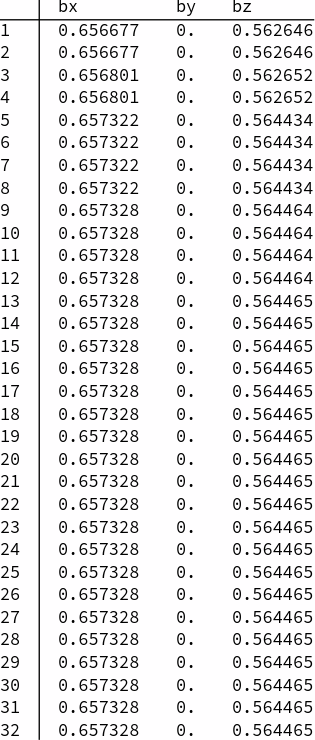

In [182]:
(* Harmonics (amplitude) convergence *)

harmonics = Range[32] ;
TableForm[
	N[Chop[Transpose[Sqrt[Map[Accumulate, Transpose[Table[amplitude[magnet, "b", lp, center, harmonic, "SamplesPerHarmonic" -> 64], {harmonic, harmonics}]]^2]]], 10.0^-6]],
	TableHeadings -> {harmonics, {"bx", "by", "bz"}}
]

In [185]:
(* Field graphics *)

ClearAll[bx, by, bz] ; 
bx[x_?NumericQ, y_?NumericQ, z_?NumericQ] := radFld[magnet, "bx", {x, y, z}] ;
by[x_?NumericQ, y_?NumericQ, z_?NumericQ] := radFld[magnet, "by", {x, y, z}] ;
bz[x_?NumericQ, y_?NumericQ, z_?NumericQ] := radFld[magnet, "bz", {x, y, z}] ;

ClearAll[b] ;
b[x_, y_, z_] := {bx[x, y, z], by[x, y, z], bz[x, y, z]} ;

field = VectorPlot3D[
  b[x, y, z],
  {x, -0.75*lx, +0.75*lx}, {y, -lp/2, +lp/2}, {z, -1.5*lz, +1.5*lz},
  VectorPoints -> {16, 64, 8},
  Lighting -> "Neutral",
  VectorScale -> {Small, 0.2, None},
  VectorStyle -> Directive[{Opacity[0.25]}],
  VectorColorFunction -> Hue,
  ColorFunctionScaling -> True
] ;

graphics = Show[Graphics3D[{EdgeForm[None], LightBlue, Opacity[0.25], radObjDrw[magnet]}, PlotRange -> {All, {-lp/2, +lp/2}, All}, ImageSize -> 1000], field, Boxed -> False] ;

# Integration parameters

In [194]:
(* Define min and max positions (mm) where magnetic field can be negnected *)

shift = 1000.0 ;
ymin = - lp*np/2 - shift ;
ymax = + lp*np/2 + shift ;

Chop[{radFld[magnet, "bx", {0.0, ymin, 0.0}], radFld[magnet, "by", {0.0, ymin, 0.0}], radFld[magnet, "bz", {0.0, ymin, 0.0}]}, 10.0^-6]
Chop[{radFld[magnet, "bx", {0.0, ymax, 0.0}], radFld[magnet, "by", {0.0, ymax, 0.0}], radFld[magnet, "bz", {0.0, ymax, 0.0}]}, 10.0^-6]

{0, 0, 0}
{0, 0, 0}

In [200]:
(* Define the integration step length (mm) and number of integration steps *)
(* Note: the integration step size is very small here; this is done for illustrative purposes *)
(* For practical computations, it can be increased significantly to reduce computation time *)

step = 0.25 ;
ypts = Floor[(ymax - ymin)/step] ;

# Lattice parameters

In [205]:
(* Reference enegry (GeV) *)

energy = 3.0 ;

In [207]:
(* Twiss parameters at ID (m) *)
(* Note, not used in this demo *)

bx$id = 8.0 ;
by$id = 2.0 ;

# Orbit matching

In [211]:
(* Orbit-matching corrections *)
(* In general, a zero initial condition at the minimum longitudinal position will not be mapped to zero at the maximum longitudinal position *)
(* This is due to the mean orbit not aligning with the field symmetry axes *)
(* A correction to enforce a zero-to-zero mapping can be computed by solving a fixed-point problem *)
(* These corrections (and the resulting mismatch) are normally very small and can be neglected (their effect on the transport matrix is also small) *)
(* Effects from real construction errors are expected to be much stronger *)
(* Additionally, they might take a long time to compute depending on the complexity of the ID geometry *)

In [218]:
(* Compute corrections *)

ClearAll[corrections] ;
corrections[object_, energy_, delta_, {start_, stop_}, steps_, solver_:radFldPtcTrj][{cxi_, czi_, cxf_, czf_}] := Block[
	{qx, px, qz, pz},
	{qx, px, qz, pz} = {0.0, 0.0, 0.0, 0.0} ;
	{qx, px, qz, pz} = {qx, px + cxi, qz, pz + czi} ;
	{qx, px, qz, pz} = transport[object, energy, delta, {start, stop}, steps, {0.0, 0.0, 0.0, 0.0}, solver, "Thin" -> False][{qx, px, qz, pz}] ;
	{qx, px, qz, pz} = {qx, px + cxf, qz, pz + czf} ;
	{qx, px, qz, pz}
] ;

ClearAll[angles] ;
ClearAll[cxi, czi, cxf, czf] ;

solution = FindRoot[
	corrections[magnet, energy, 0.0, {ymin, ymax}, ypts][{cxi, czi, cxf, czf}] == 0, 
	{{cxi, 0.0}, {czi, 0.0}, {cxf, 0.0}, {czf, 0.0}}, 
	Evaluated -> False,
	Compiled -> False
] ;

angles = {cxi, czi, cxf, czf} = {cxi, czi, cxf, czf} /. solution ;
angles

-7            -10            -7             -10
{2.49062 10  , 6.83764 10   , 2.49062 10  , -6.83339 10   }

In [226]:
(* Set correction values to skip long comutation *)

ClearAll[angles] ;
ClearAll[cxi, czi, cxf, czf] ;

angles = {cxi, czi, cxf, czf} = {2.4906259041062194*^-7, 6.831144216727172*^-10, 2.4906284546525633*^-7, -6.835463939423848*^-10} ;

In [230]:
(* Test corrections matching *)

initial = {0.0, 0.0, 0.0, 0.0} ;
transport[magnet, energy, 0.0, {ymin, ymax}, ypts, 0.0*angles, radFldPtcTrj, "Thin" -> True][initial] - initial // Abs // Chop // N
transport[magnet, energy, 0.0, {ymin, ymax}, ypts, 1.0*angles, radFldPtcTrj, "Thin" -> True][initial] - initial // Abs // Chop // N

-9            -7           -9            -10
{4.88298 10  , 5.16014 10  , 3.7985 10  , 3.09681 10   }
{0., 0., 0., 0.}

# Reference trajectory

In [234]:
(* radFldPtcTrj[obj, E, {x0, dxdy0, z0, dzdy0}, {y0, y1}, np]      -- Radia RK integration          *)
(* RadFldPtcTrj[obj, E, {x0, dxdy0, z0, dzdy0}, {y0, y1}, np]      -- NDSolve integration           *)
(* RadFldPtcTrjCnn[obj, E, dE, {qx0, px0, qz0, pz0}, {y0, y1}, np] -- NDSolve canonical integration *)

{0., 0., 0., 0.}
                         -7             -6             -10
{-0.00123768, -2.66951 10  , -3.05307 10  , -3.73858 10   }
-Graphics-   -Graphics-
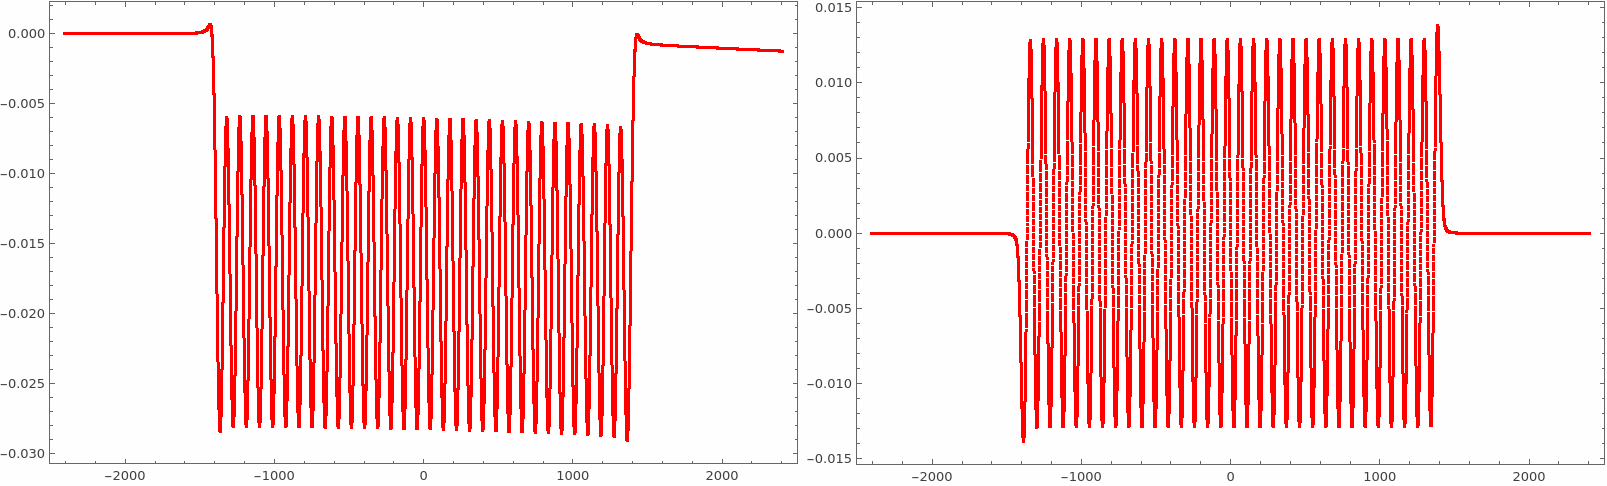

In [237]:
(* Ideal on-energy orbit (no matching) *)

delta = 0.0 ;
initial = {0.0, 0.0, 0.0, 0.0}
initial = initial + 0.0*{0.0, cxi, 0.0, czi} ;
{positions, xs, xps, zs, zps} = Transpose[radFldPtcTrj[magnet, energy*(1 + delta), initial, {ymin, ymax}, ypts]] ;
Map[Last, {xs, xps, zs, zps}] + 1.0*{0.0, cxf, 0.0, czf} // Chop // N

pltx = ListPlot[Transpose[{positions, xs}],  PlotStyle -> Red,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;
plty = ListPlot[Transpose[{positions, zs}],  PlotStyle -> Red,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;
Grid[{{Show[pltx, PlotRange -> All], Show[plty, PlotRange -> All]}}]

{0., 0., 0., 0.}
           -10                 -9
{6.00684 10   , 0., -3.45497 10  , 0.}
-Graphics-   -Graphics-
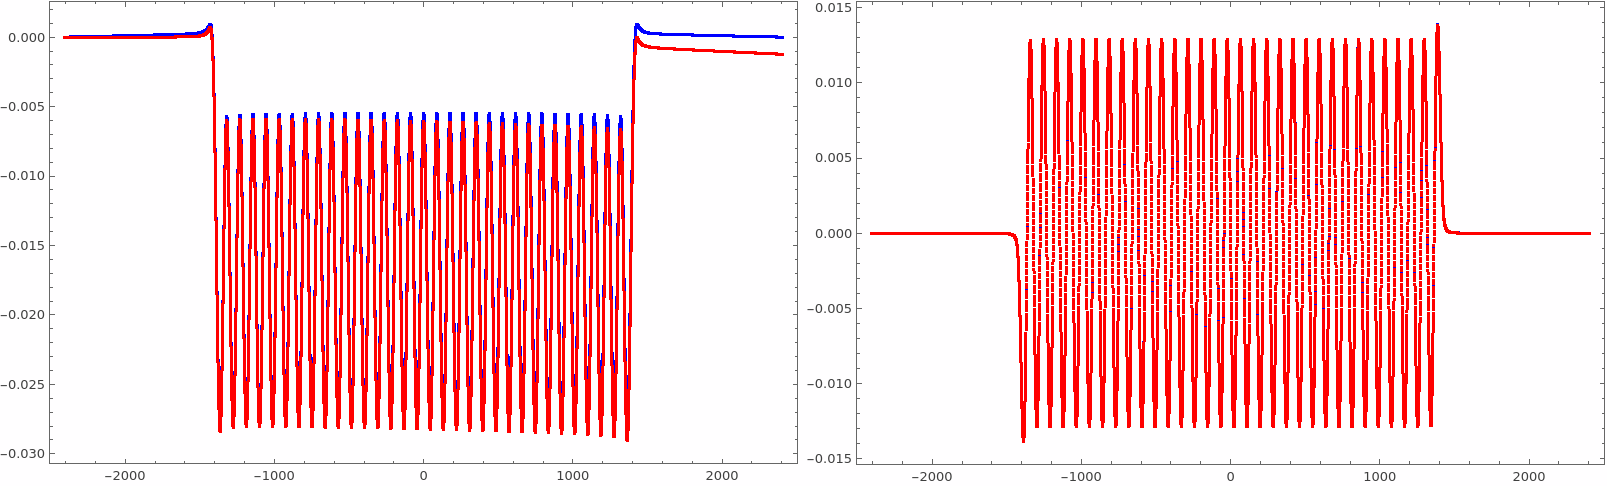

In [246]:
(* Ideal on-energy orbit (matching) *)

delta = 0.0 ;
initial = {0.0, 0.0, 0.0, 0.0}
initial = initial + 1.0*{0.0, cxi, 0.0, czi} ;
{positions, xs, xps, zs, zps} = Transpose[radFldPtcTrj[magnet, energy*(1 + delta), initial, {ymin, ymax}, ypts]] ;
Map[Last, {xs$matched, xps$matched, zs$matched, zps$matched} = {xs, xps, zs, zps}] + 1.0*{0.0, cxf, 0.0, czf} // Chop // N

pltx$matched = ListPlot[Transpose[{positions, xs}],  PlotStyle -> Blue,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;
plty$matched = ListPlot[Transpose[{positions, zs}],  PlotStyle -> Blue,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;

Grid[{{Show[pltx$matched, pltx, PlotRange -> All], Show[plty$matched, plty, PlotRange -> All]}}]

-Graphics-
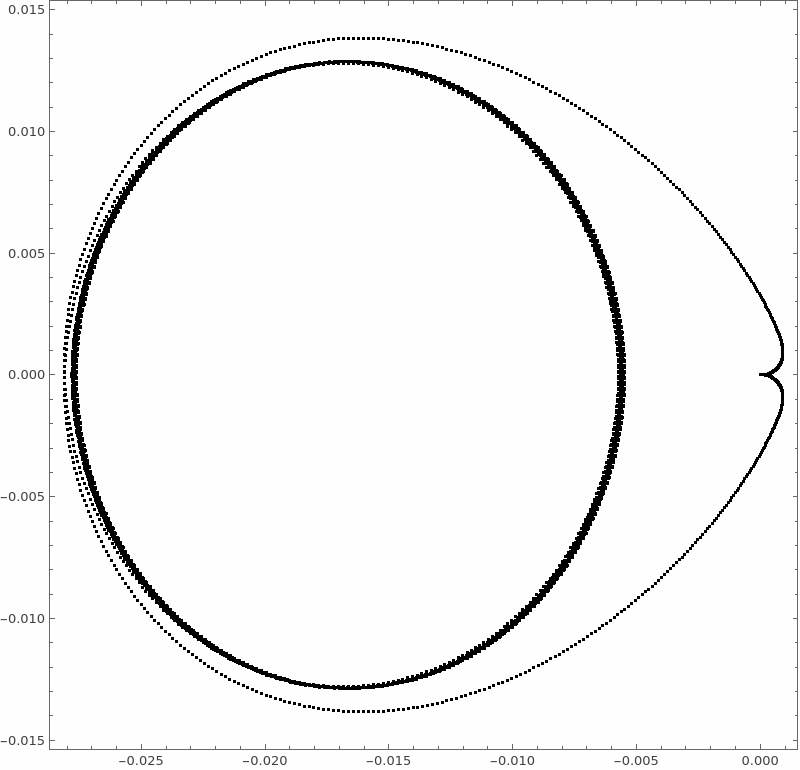

In [255]:
(* Plot x vs z *)

ListPlot[Transpose[{xs, zs}],  PlotStyle -> Black,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False, AspectRatio -> 1]

In [257]:
(* Plot 3D trajectory (magnified) *)

ClearAll[bx, by, bz] ; 
bx[x_?NumericQ, y_?NumericQ, z_?NumericQ] := radFld[magnet, "bx", {x, y, z}] ;
by[x_?NumericQ, y_?NumericQ, z_?NumericQ] := radFld[magnet, "by", {x, y, z}] ;
bz[x_?NumericQ, y_?NumericQ, z_?NumericQ] := radFld[magnet, "bz", {x, y, z}] ;

ClearAll[b] ;
b[x_, y_, z_] := {bx[x, y, z], by[x, y, z], bz[x, y, z]} ;

field = VectorPlot3D[
  b[x, y, z],
  {x, -0.75*lx, +0.75*lx}, {y, -lp/2, +lp/2}, {z, -1.5*lz, +1.5*lz},
  VectorPoints -> {16, 32, 8},
  Lighting -> "Neutral",
  VectorScale -> {Small, 0.25, None},
  VectorStyle -> Directive[{Opacity[0.50]}],
  VectorColorFunction -> Hue,
  ColorFunctionScaling -> True
] ;

factor = 250.0 ;

graphics = Show[
	Graphics3D[{EdgeForm[None], LightBlue, Opacity[0.25], radObjDrw[magnet]}, PlotRange -> {All, {-lp/2, +lp/2}, All}, ImageSize -> 1000], 
	ListPointPlot3D[Transpose[{factor*xs, positions, factor*zs}]],
	field,
	Boxed -> False
] ;

-Graphics-   -Graphics-
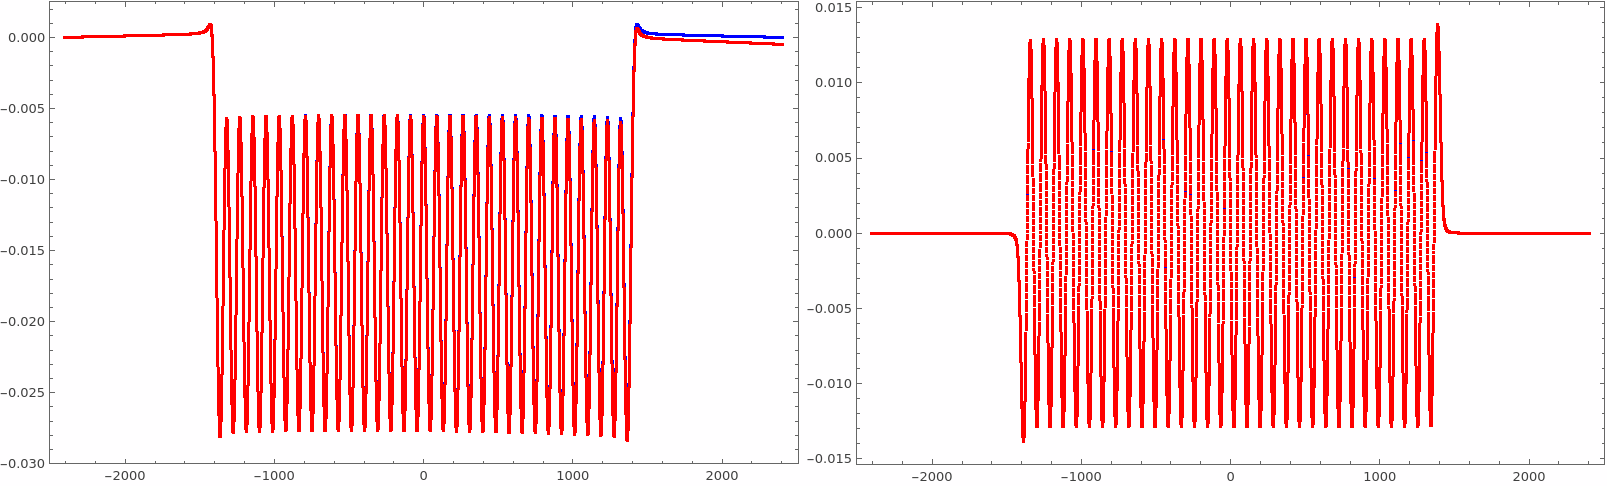

In [267]:
(* Integrate ideal on-energy orbit (NDSolve) *)

delta = 0.0 ;
initial = {0.0, 0.0, 0.0, 0.0} ;
initial = initial + 1.0*{0.0, cxi, 0.0, czi} ;
{positions, xs, xps, zs, zps} = Transpose[RadFldPtcTrj[magnet, energy*(1 + delta), initial, {ymin, ymax}, ypts, Method -> {"FixedStep", Method -> {"StiffnessSwitching", Method -> {"ExplicitRungeKutta", Automatic}}}]] ;

pltx = ListPlot[Transpose[{positions, xs}],  PlotStyle -> Red,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;
plty = ListPlot[Transpose[{positions, zs}],  PlotStyle -> Red,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;

Grid[{{Show[pltx$matched, pltx, PlotRange -> All], Show[plty$matched, plty, PlotRange -> All]}}]

-Graphics-   -Graphics-
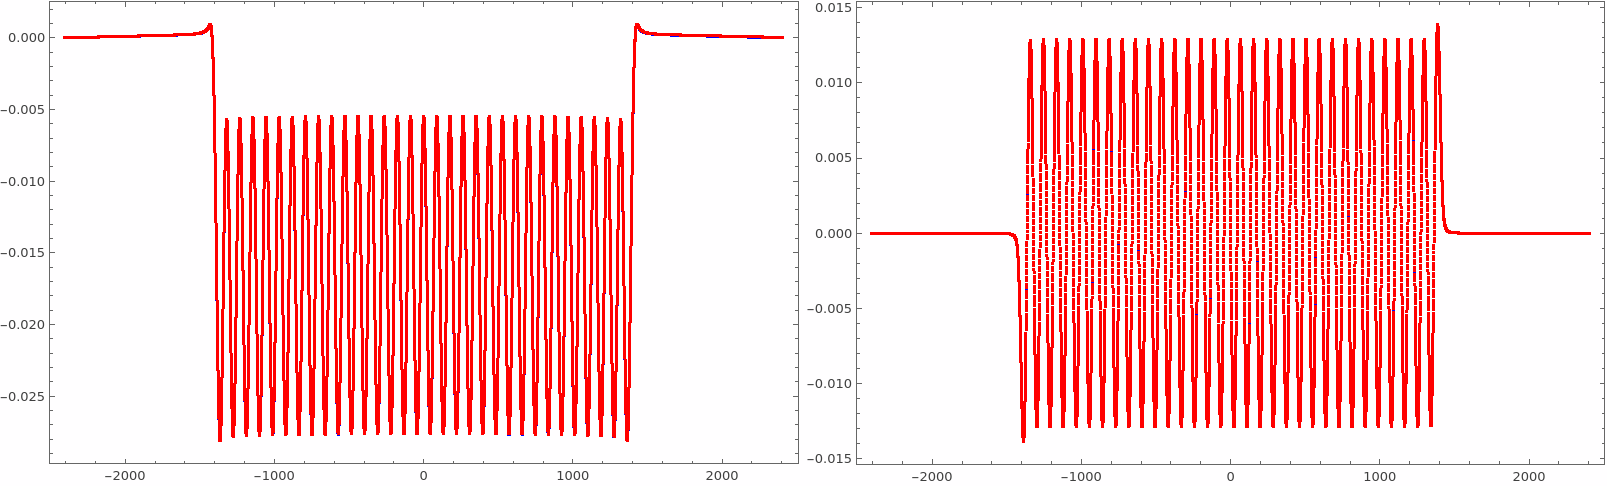

In [275]:
(* Integrate ideal on-energy orbit (NDSolve & canonical tracking) *)
(*  Note, external fields are assumed to be normalized *)

ClearAll[extAx, extAy, extAz] ;
extAx[x_, y_, z_] := 0.0 ;
extAy[x_, y_, z_] := 0.0 ;
extAz[x_, y_, z_] := 0.0 ;

delta = 0.0 ;
initial = {0.0, 0.0, 0.0, 0.0} ;
initial = initial + 1.0*{0.0, cxi, 0.0, czi} ;
{positions, qxs, pxs, qzs, pzs} = Transpose[RadFldPtcTrjCnn[magnet, energy, delta, initial, {ymin, ymax}, ypts, {extAx, extAy, extAz}, Method -> {"FixedStep", Method -> {"StiffnessSwitching", Method -> {"ExplicitRungeKutta", Automatic}}}]] ;

pltx = ListPlot[Transpose[{positions, qxs}],  PlotStyle -> Red,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;
plty = ListPlot[Transpose[{positions, qzs}],  PlotStyle -> Red,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;

Grid[{{Show[pltx$matched, pltx, PlotRange -> All], Show[plty$matched, plty, PlotRange -> All]}}]

-Graphics-   -Graphics-
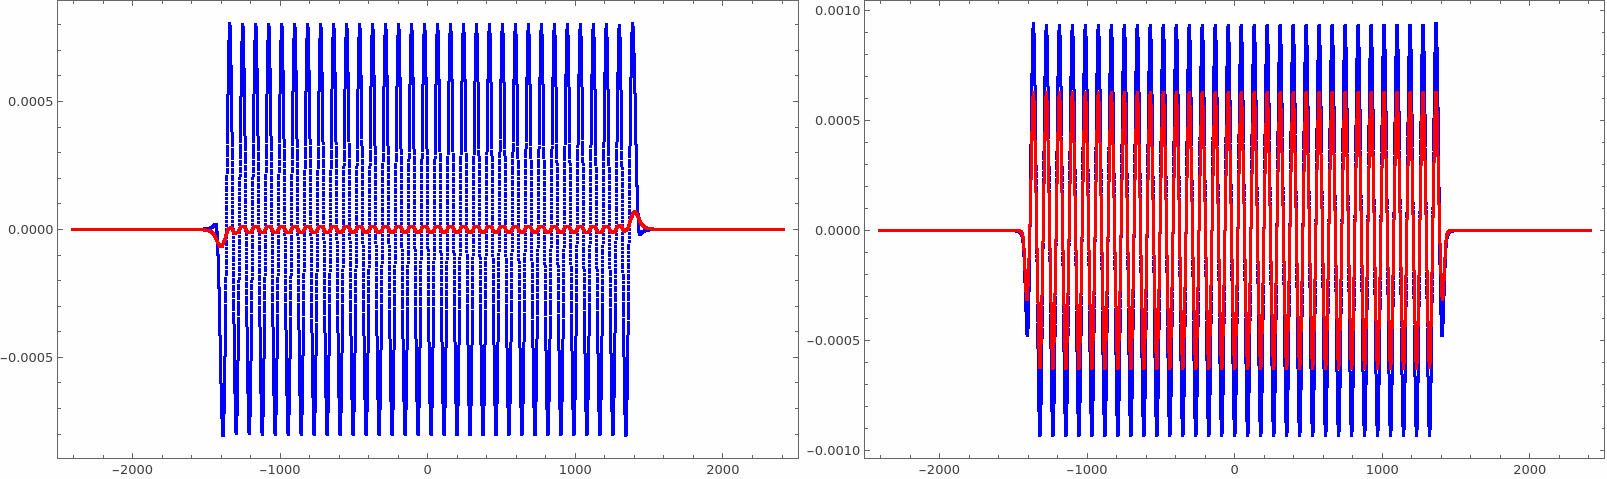

In [288]:
(* Slopes vs canonical momenta *)

pltx$matched = ListPlot[Transpose[{positions, xps$matched}],  PlotStyle -> Blue,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;
plty$matched = ListPlot[Transpose[{positions, zps$matched}],  PlotStyle -> Blue,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;

pltx = ListPlot[Transpose[{positions, pxs}],  PlotStyle -> Red,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;
plty = ListPlot[Transpose[{positions, pzs}],  PlotStyle -> Red,  PlotRange -> All, ImageSize -> 600, Frame -> True, Axes -> False] ;

Grid[{{Show[pltx$matched, pltx, PlotRange -> All], Show[plty$matched, plty, PlotRange -> All]}}]

In [294]:
(* For some reason, canonical tracking matches Radia's RK results much better *)
(* The integration method used, or the step size, does not seem to resolve the discrepancy when using RadFldPtcTrj (slope-based solver) *)
(* If you know the reason why RadFldPtcTrj does not match Radia's RK well, send me an email. Cheers! *)

# Elleaume's potential

In [297]:
(* Given the magnetic field, one can compute Elleaume's potential for one ID period *)
(* This potential is used to compute the transverse momentum kicks *)
(* The integral for the potential is approximated by a truncated Fourier representation of the periodic magnetic field *)
(* For a fixed transverse position, one or more harmonics of the field components are computed over one period from numerical field samples *)
(* The one-period potential is then approximated from the amplitudes of these harmonics *)
(* This is the default method used to compute potential values *)

6486.36

6486.36

6486.53

6486.53

6487.59
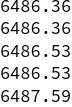

In [303]:
(* Compare potential values for different number of harmonics used *)

Table[potential[magnet, {1.0, 1.0}, {lp, lp}, Range[n], 0.0, "SamplesPerHarmonic" -> 32], {n, 1, 5, 1}] // TableForm

In [305]:
(* Alternatively, one can compute the potential using numerical integration *)
(* Note, for direct numerical integration, integration method and accuracy goal should be passed *)

potential[magnet, {1.0, 1.0}, {lp, lp}, {1}, 0.0, "SamplesPerHarmonic" -> 32]
potential[magnet, {1.0, 1.0}, {lp, lp}, {1, 2}, 0.0, "NIntegrate" -> True, AccuracyGoal -> 3, Method -> "LocalAdaptive"]

6486.36
6487.6

-Graphics-
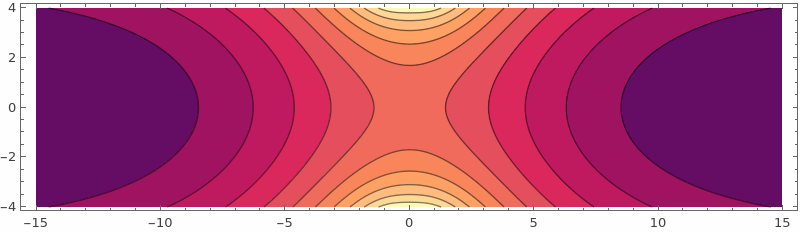

In [309]:
(* Plot potential level set *)

{xmin, xmax} = {-15.0, +15.0} ;
{zmin, zmax} = {-4.0, +4.0} ;

ContourPlot[
	potential[magnet, {x, y}, {lp, lp}, {1}, 0.0, "SamplesPerHarmonic" -> 32],
	{x, xmin, xmax}, 
	{y, zmin, zmax}, 
	AspectRatio -> (zmax - zmin)/(xmax - xmin), 
	PlotPoints -> 100, 
	ImageSize -> 600, 
	Contours -> 10
]

# Tracking (Elleaume's potential)

In [313]:
(* The DKD function can be used to perform canonical tracking using Elleaume's potential *)
(* Similarly to RK-based tracking, canonical coordinates are used and the element is represented as a thin nonlinear insertion *)
(* Each ID period is a drift-kick-drift sequence, where the kick angles are computed from Elleaume's potential *)
(* Unlike kick maps, the kick angles are not precomputed on a grid, but are computed on demand given the transverse coordinates *)
(* In all computations, the first four harmonics are used, with the number of samples equal to 32 x harmonic number *)

In [318]:
(* Set the on-orbit canonical initial condition for the tracking comparison *)
(* This canonical initial condition corresponds to the ID center *) 
(* Coordinates are in meters *)

delta = 0.0 ;
initial = {0.25, 0.0, 0.25, 0.0}*10.0^-3 ;

In [323]:
(* Compute final value with radFldPtcTrj solver *)

final = transport[magnet, energy, delta, {ymin, ymax}, ypts, angles, radFldPtcTrj, "Thin" -> True][initial]

-6                          -6
{0.000250159, 7.4999 10  , 0.000250078, -9.82598 10  }

In [325]:
(* Potential tracking (single kick at the ID center) *)
(* Here, the dxp and dzp angles are computed explicitly for one ID period and multiplied by the number of periods *)
(* Input coordinates are in mm, and the output angles are in microradians *)

{qx, px, qz, pz} = initial ;
{x, xp, z, zp} = {qx, px/Sqrt[(1 + delta)^2 - px^2 - pz^2], qz, pz/Sqrt[(1 + delta)^2 - px^2 - pz^2]} ;
cx = np*dxp[magnet, 10.0^3*{x, z}, {lp, lp}, {1, 2, 3, 4}, 0.0, energy*(1 + delta), 0.1, "SamplesPerHarmonic" -> 32]*10^-6 ;
cz = np*dzp[magnet, 10.0^3*{x, z}, {lp, lp}, {1, 2, 3, 4}, 0.0, energy*(1 + delta), 0.1, "SamplesPerHarmonic" -> 32]*10^-6 ;
{x, xp, z, zp} = {x, xp - cx, z, zp - cz} ;
{qx, px, qz, pz} = {x, (1 + delta)*xp/Sqrt[1 + xp^2 + xp^2], z, (1 + delta)*zp/Sqrt[1 + xp^2 + zp^2]} ;
final$1k = {qx, px, qz, pz} ;

final$1k - final // Abs

-7           -8            -8            -7
{1.59206 10  , 2.7639 10  , 7.77046 10  , 2.70368 10  }

In [336]:
(* Equivalently, the computation can be performed using the DKD function *)
(* With the number of periods set to one and the extra angle multiplication factors set to the number of periods *)

final$1k = dkd[magnet, energy, delta, {lp, lp}, {1, 2, 3, 4}, 0.0, 0.1, 1, {np, np}, "SamplesPerHarmonic" -> 32][initial] ;
final$1k - final // Abs

-7            -8            -8            -7
{1.59206 10  , 2.76389 10  , 7.77046 10  , 2.70368 10  }

In [340]:
(* Perform tracking using one kick per ID period *)

final$nk = dkd[magnet, energy, delta, {lp, lp}, {1, 2, 3, 4}, 0.0, 0.1, np, {1, 1}, "SamplesPerHarmonic" -> 32][initial] ;
final$1k - final // Abs
final$nk - final // Abs

-7            -8            -8            -7
{1.59206 10  , 2.76389 10  , 7.77046 10  , 2.70368 10  }
           -7            -8            -7            -8
{2.32106 10  , 7.57776 10  , 2.12469 10  , 7.85548 10  }

# Energy-dependent orbit

In [344]:
(* Compute the orbit derivative with respect to energy deviation using a central finite difference *)
(* This effect is very small even for more realistic IDs models *)

In [346]:
delta = 0.0001 ;
initial = {0.0, 0.0, 0.0, 0.0} ;
positive = transport[magnet, energy, +delta, {ymin, ymax}, ypts, angles, radFldPtcTrj, "Thin" -> True][initial] ;
negative = transport[magnet, energy, -delta, {ymin, ymax}, ypts, angles, radFldPtcTrj, "Thin" -> True][initial] ;
dispersion = (positive - negative)/(2*delta) ;
N[Chop[dispersion, 10.0^-6]]

-6
{0., 1.00336 10  , 0., 0.}

In [352]:
delta = 0.001 ;
initial = {0.0, 0.0, 0.0, 0.0} ;
positive = transport[magnet, energy, +delta, {ymin, ymax}, ypts, angles, radFldPtcTrj, "Thin" -> True][initial] ;
negative = transport[magnet, energy, -delta, {ymin, ymax}, ypts, angles, radFldPtcTrj, "Thin" -> True][initial] ;
dispersion = (positive - negative)/(2*delta) ;
N[Chop[dispersion, 10.0^-6]]

-6
{0., 1.00343 10  , 0., 0.}

In [358]:
ClearAll[wrapper] ;
wrapper[delta_?NumericQ] := transport[magnet, energy, delta, {ymin, ymax}, ypts, angles, radFldPtcTrj, "Thin" -> True][initial] ;

In [360]:
<< NumericalCalculus`
N[Chop[ND[wrapper[δ], δ, 0.0, Method -> "CentralDifference"], 10.0^-6]]

-6
{0., 1.00341 10  , 0., 0.}

# Transport matrix (RK integrator)

In [362]:
(* Given a black-box thin nonlinear insertion mapping, the corresponding transport matrix can be extracted by tracking several initial conditions close to the origin *)
(* The resulting matrix is not symplectic, but it is expected to be close to a symplectic one *)
(* A standard symplectification procedure can then be applied to obtain a symplectic matrix that can be used to model the ID's effect on linear optics *)
(* The exponential representation can be computed from this matrix, yielding a redundancy-free representation and providing a link to the time-one Hamiltonian and monomials with dominant coefficients *)
(* Alternatively, one can proceed without symplectification to compute the exponent and then perform symmetrization *)

In [367]:
(* Set the on-orbit canonical initial condition for the tracking comparison *)
(* This canonical initial condition corresponds to the ID center *) 
(* Coordinates are in meters *)

delta = 0.0 ;
initial = {0.25, 0.0, 0.25, 0.0}*10.0^-3 ;

In [372]:
(* Compute final value with radFldPtcTrj solver *)

final = transport[magnet, energy, delta, {ymin, ymax}, ypts, angles, radFldPtcTrj, "Thin" -> True][initial]

-6                          -6
{0.000250159, 7.4999 10  , 0.000250078, -9.82598 10  }

-8
2.12194 10
0.999717        -0.0189308     0.00091209     0.0000197187

0.0299467       0.999717       0.0000298482   -0.000824004

0.000824004     -0.000019711   0.999486       0.0261814

-0.0000298512   -0.000912083   -0.0392693     0.999486
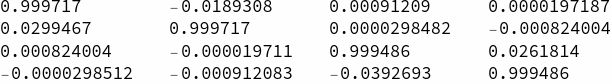

In [374]:
(* Initial transport matrix generation *)
(* Track eight initial conditions epsilon-close to the origin using radFldPtcTrj *)

epsilon = 0.00001 ;
M = matrix[magnet, energy, delta, {ymin, ymax}, ypts, angles, epsilon, radFldPtcTrj, "Thin" -> True] ;
1 - Det[M] // Abs
M // TableForm

-16
1.11022 10
0.999717        -0.0189308      0.000912086    0.000019751

0.0299467       0.999717        0.0000298463   -0.000824004

0.000824004     -0.0000197434   0.999486       0.0261814

-0.0000298494   -0.000912086    -0.0392693     0.999486
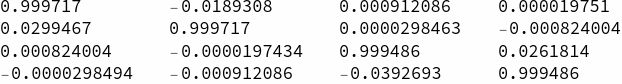

In [380]:
(* Perform transport matrix symplectification *)
(* The minimal linear perturbation corresponds to the identity matrix *)

M = symplectify[M] ;
1 - Det[M] // Abs
M // TableForm

In [385]:
(* Perform transport matrix tracking *)

final$matrix = M.initial ;
final$matrix - final // Abs

-9            -9            -10            -9
{1.96408 10  , 5.76995 10  , 1.61421 10   , 1.19118 10  }

-9             -9
-0.0299495     4.32697 10     1.55969 10      0.000824342

          -9                                            -9
4.32697 10     -0.0189326     0.00091243      3.79073 10

          -9                                             -8
1.55969 10     0.00091243     0.039276        -1.39491 10

                         -9              -8
0.000824342    3.79073 10     -1.39491 10     0.0261859
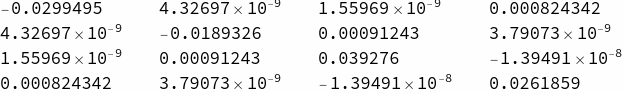

In [388]:
(* Compute transport matrix exponential parameterization M = exp(S A) *)

S = identity[1 + 1] ;
A$RK = - S . MatrixLog[M] // Re ;
A$RK // TableForm

-0.0299495    0.           0.           0.000824342

0.            -0.0189326   0.00091243   0.

0.            0.00091243   0.039276     0.

0.000824342   0.           0.           0.0261859
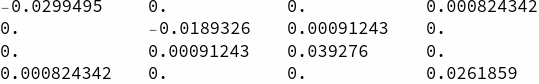

In [392]:
(* For APPLE-II type IDs, the skew-diagonal elements are nonzero, but several orders of magnitude smaller than the main-diagonal ones *)
(* Additionally, the uncoupled blocks are nearly diagonal, meaning the corresponding uncoupled-block Hamiltonian does not contain cross terms *)
(* In total, 6 parameters are required to parameterize the linear on-energy transport matrix: 4 elements on the main diagonal and 2 on the skew diagonal *)

Chop[A$RK, 10.0^-6] // N // TableForm

In [396]:
(* The corresponding time-one Hamiltonian has a solenoid-like component *)
(* This corresponds to the QX PZ and PX QZ monomial coefficients being nonzero *)

Expand[Chop[1/2 {QX, PX, QZ, PZ} . A$RK . {QX, PX, QZ, PZ}, 10.0^-6]]

2               2                                   2
-0.0094663 PX  + 0.0130929 PZ  + 0.000824342 PZ QX - 0.0149748 QX  + 0.00091243 PX QZ + 
 
               2
>   0.019638 QZ

In [399]:
(* To account for chromatic effects, the transport matrix can be factorized as M(dp) = exp(S A) exp(dp S B) exp(dp^2 S C) ... *)
(* The analytical construction can be derived using the Magnus expansion *)
(* Leading-order effects are captured by the B matrix, which is symmetric and, in general, has 10 independent elements *)
(* Expanding in a series M(dp) = M(0) + (dM/ddp)(0) dp + ... = M(0) (I + dp S B + ... ) *)
(* Matching the terms gives B = -S exp(-S A) (dM/ddp)(0) *)
(* The derivative (dM/ddp)(0) can be computed by tracking via a central finite difference: (dM/ddp)(0) = (M(+\[CapitalDelta]) - M(-\[CapitalDelta]))/(2 \[CapitalDelta]) *)
(* The B matrix should be close to symmetric *)
(* B = 1/2 (B + Transpose[B]) enforces symmetry *)

In [407]:
(* Compute transport matrix derivative with respect to energy deviatino *)

epsilon = 0.0001 ;
delta = 0.0001 ;
positive = matrix[magnet, energy, + delta, {ymin, ymax}, ypts, angles, epsilon, radFldPtcTrj, "Thin" -> True] ;
negative = matrix[magnet, energy, - delta, {ymin, ymax}, ypts, angles, epsilon, radFldPtcTrj, "Thin" -> True] ;
dMddp = (positive - negative)/2/delta ;

-6
0.0307692      0.000555868     5.52318 10     -0.00170215

                                                       -6
0.000540482    0.0564399       -0.0017519     5.7451 10

          -6
4.58102 10     -0.00175957     -0.0378717     0.00105253

-0.00170181    -0.0000103703   0.00106387     -0.079199
                                       -6
0.0307692     0.000548175     5.0521 10     -0.00170198

                                                       -6
0.000548175   0.0564399       -0.00175574   -2.31261 10

         -6
5.0521 10     -0.00175574     -0.0378717    0.0010582

                         -6
-0.00170198   -2.31261 10     0.0010582     -0.079199
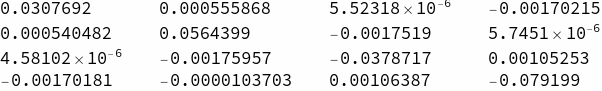
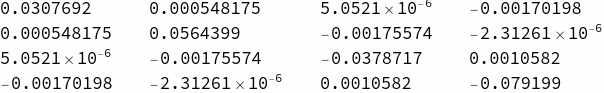

In [413]:
(* Compute the exponent matrix *)
(* As with the orbit derivative, the elements of the leading-order chromatic matrix are rather small *)

B$RK = - S . MatrixExp[- S . A$RK] . dMddp ;
B$RK // TableForm

B$RK = 1/2 (B$RK + Transpose[B$RK]) ; 
B$RK // TableForm

# Transport matrix (Elleaume's potential)

In [419]:
(* Define parametric transport matrix (single kick) *)

ClearAll[m1k] ;
m1k[delta_, epsilon_] := Block[
	{positive, negative},
	positive = dkd[magnet, energy, delta, {lp, lp}, {1, 2, 3, 4}, 0.0, 0.1, 1, {np, np}, "SamplesPerHarmonic" -> 32] /@ (+epsilon*IdentityMatrix[4]) ;
	negative = dkd[magnet, energy, delta, {lp, lp}, {1, 2, 3, 4}, 0.0, 0.1, 1, {np, np}, "SamplesPerHarmonic" -> 32] /@ (-epsilon*IdentityMatrix[4]) ;
	symplectify[Transpose[(positive - negative)/(2*epsilon)]]
] ;

In [422]:
(* Compute on-energy transport matrix and corresponding exponent *)

M$1K = m1k[0.0*delta, epsilon] ;
A$1K = - S . MatrixLog[M$1K] // Re ;

In [425]:
(* Compute leading order chromatic matrix and corresponding exponent *)

positive = m1k[+delta, epsilon] ;
negative = m1k[-delta, epsilon] ;
dMddp = (positive - negative)/2/delta ;

B$1K = - S . MatrixExp[- S . A$1K] . dMddp ;
B$1K = 1/2 (B$1K + Transpose[B$1K]) ; 

In [431]:
(* Define parametric transport matrix (one kick per period) *)

ClearAll[mnk] ;
mnk[delta_, epsilon_] := Block[
	{positive, negative},
	positive = dkd[magnet, energy, delta, {lp, lp}, {1, 2, 3, 4}, 0.0, 0.1, np, {1, 1}, "SamplesPerHarmonic" -> 32] /@ (+epsilon*IdentityMatrix[4]) ;
	negative = dkd[magnet, energy, delta, {lp, lp}, {1, 2, 3, 4}, 0.0, 0.1, np, {1, 1}, "SamplesPerHarmonic" -> 32] /@ (-epsilon*IdentityMatrix[4]) ;
	symplectify[Transpose[(positive - negative)/(2*epsilon)]]
] ;

In [434]:
(* Compute on-energy transport matrix and corresponding exponent *)

M$NK = mnk[0.0*delta, epsilon] ;
A$NK = - S . MatrixLog[M$NK] // Re ;

In [437]:
(* Compute leading order chromatic matrix and corresponding exponent *)

positive = mnk[+delta, epsilon] ;
negative = mnk[-delta, epsilon] ;
dMddp = (positive - negative)/2/delta ;

B$NK = - S . MatrixExp[- S . A$NK] . dMddp ;
B$NK = 1/2 (B$NK + Transpose[B$NK]) ; 

-0.0298529   0.   0.          0.

0.           0.   0.          0.

0.           0.   0.0404091   0.

0.           0.   0.          0.
-0.0302751   0.           0.          0.

0.           -0.0195412   0.          0.

0.           0.           0.0396543   0.

0.           0.           0.          0.0269846
-0.0299495    0.           0.           0.000824342

0.            -0.0189326   0.00091243   0.

0.            0.00091243   0.039276     0.

0.000824342   0.           0.           0.0261859
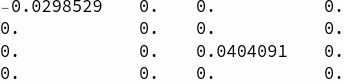
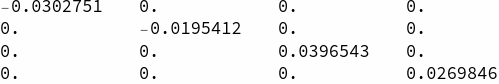
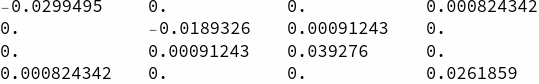

In [443]:
(* Compare results with RK tracking *)

(* Several main observations: *)

(* 1. The matrix computed from a single kick contains only the elements corresponding to focusing strength *)
(* 2. The one-kick-per-period matrix is diagonal *)
(* 3. Its diagonal elements match the RK result closely (this is usually the case for long IDs; for short IDs with matching sections, the difference is more pronounced) *)
(* 4. The skew diagonal, while small, is present only in the RK result *)

Chop[A$1K, 10.0^-6] // N // TableForm
Chop[A$NK, 10.0^-6] // N // TableForm
Chop[A$RK, 10.0^-6] // N // TableForm

-6
0.0298587       0.              0.              -2.24258 10

                                           -6
0.              0.              -1.74714 10     0.

                           -6                            -6
0.              -1.74714 10     -0.0404065      -1.254 10

           -6                            -6
-2.24258 10     0.              -1.254 10       0.
0.0311414     0.000577805   0.           0.

0.000577805   0.0582638     0.           0.

0.            0.            -0.0381967   0.00110162

0.            0.            0.00110162   -0.0815743
                                       -6
0.0307692     0.000548175     5.0521 10     -0.00170198

                                                       -6
0.000548175   0.0564399       -0.00175574   -2.31261 10

         -6
5.0521 10     -0.00175574     -0.0378717    0.0010582

                         -6
-0.00170198   -2.31261 10     0.0010582     -0.079199
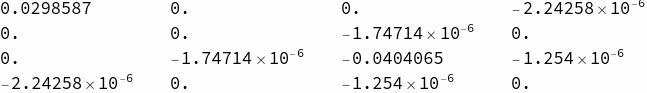
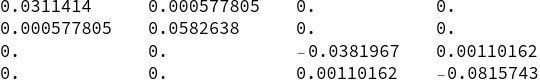
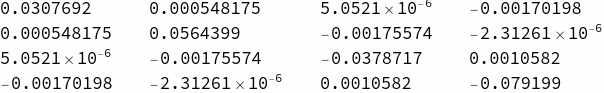

In [452]:
(* Compare leading order chromatic exponents *)

Chop[B$1K, 10.0^-6] // N // TableForm
Chop[B$NK, 10.0^-6] // N // TableForm
Chop[B$RK, 10.0^-6] // N // TableForm

# Transport matrix (approximate linear semi-analytical ID model)

In [456]:
(* Elleaume's potential can be used to compute the linear focusing parameters kx and kz (note that the mixed derivative is ignored here; it corresponds to a linear skew kick) *)
(* This allows constructing a parametric model for the ID transport matrix depending on lp, np, and the focusing parameters *)

In [458]:
(* Compute focusing parameters (one period) *)

KX = kx[magnet, {0.0, 0.0}, {lp, lp}, {1, 2, 3, 4}, 0.0, energy, 0.1, "SamplesPerHarmonic" -> 32]
KZ = kz[magnet, {0.0, 0.0}, {lp, lp}, {1, 2, 3, 4}, 0.0, energy, 0.1, "SamplesPerHarmonic" -> 32]

-0.000933416
0.00126219

In [461]:
np*{KX, KZ}
Diagonal[A$1K]
Diagonal[A$NK]
Diagonal[A$RK]

{-0.0298693, 0.04039}
                        -16                       -16
{-0.0298529, -4.13014 10   , 0.0404091, 2.22954 10   }
{-0.0302751, -0.0195412, 0.0396543, 0.0269846}
{-0.0299495, -0.0189326, 0.039276, 0.0261859}

In [465]:
(* Compute the on-energy transport matrix and corresponding exponent *)
(* In principle, the transport matrix can be computed exactly while keeping the full chromatic dependence *)
(* However, since kx and kz are small, IDTM uses a second-order approximation for the matrix coefficients with respect to the focusing parameters *)


M$ID = idtm[{KX, KZ}, np, lp*10.0^-3, 0.0] // Last ;
A$ID = - S . MatrixLog[M$ID] // Re ;

In [470]:
(* Compute leading order chromatic matrix *)

positive = idtm[{KX, KZ}, np, lp*10.0^-3, +delta] // Last ;
negative = idtm[{KX, KZ}, np, lp*10.0^-3, -delta] // Last ;
dMddp = (positive - negative)/2/delta ;

B$ID = - S . MatrixExp[- S . A$ID] . dMddp ;
B$ID = 1/2 (B$NK + Transpose[B$ID]) ; 

-0.0302751   0.           0.          0.

0.           -0.0195412   0.          0.

0.           0.           0.0396543   0.

0.           0.           0.          0.0269846
-0.0302876   0.          0.          0.

0.           -0.019553   0.          0.

0.           0.          0.0396251   0.

0.           0.          0.          0.0269681
-0.0299495    0.           0.           0.000824342

0.            -0.0189326   0.00091243   0.

0.            0.00091243   0.039276     0.

0.000824342   0.           0.           0.0261859
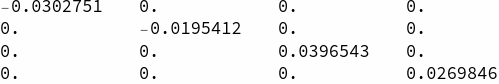
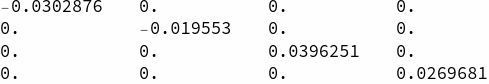
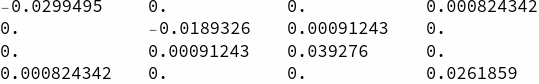

In [476]:
(* Compare on-energy transport matrix exponents *)

Chop[A$NK, 10.0^-6] // N // TableForm
Chop[A$ID, 10.0^-6] // N // TableForm
Chop[A$RK, 10.0^-6] // N // TableForm

0.0311414     0.000577805   0.           0.

0.000577805   0.0582638     0.           0.

0.            0.            -0.0381967   0.00110162

0.            0.            0.00110162   -0.0815743
0.0311387     0.000578348   0.           0.

0.000578348   0.0582916     0.           0.

0.            0.            -0.0381606   0.00110125

0.            0.            0.00110125   -0.081533
                                       -6
0.0307692     0.000548175     5.0521 10     -0.00170198

                                                       -6
0.000548175   0.0564399       -0.00175574   -2.31261 10

         -6
5.0521 10     -0.00175574     -0.0378717    0.0010582

                         -6
-0.00170198   -2.31261 10     0.0010582     -0.079199
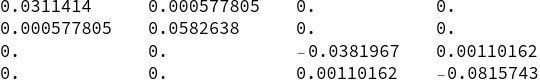
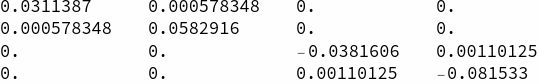
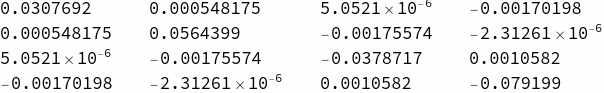

In [480]:
(* Compare leading order chromatic exponents *)

Chop[B$NK, 10.0^-6] // N // TableForm
Chop[B$ID, 10.0^-6] // N // TableForm
Chop[B$RK, 10.0^-6] // N // TableForm

# Kick maps (export and tracking)

In [484]:
(* AT-style kick map generation (export file and return all data) *)

In [485]:
(* Set region bounds *)

{xmin, xmax} = {-15.0, +15.0} ;
{zmin, zmax} = {-4.0, +4.0} ;

In [488]:
(* Compute the kick maps *)
(* Note, all sizes in the options are in mm *)
(* The map is saved to the result.mat file in the current working directory and can be used with AT *)

map = table[
    magnet,
    {lp, lp},
    {1},
    0.0,
    "XRange" -> {xmin, xmax},
    "ZRange" -> {zmin, zmax},
    "XStep" -> 0.25,
    "ZStep" -> 0.5,
    "Delta" -> 0.2,
    "Digits" -> None,
    "Point" -> {0.0, 0.0},
    "Energy" -> None,
    "KickScales" -> 10.0^-6,
    "KickSigns" -> {-1, -1},
    "Period" -> lp,
    "File" -> "result",
    "SamplesPerHarmonic" -> 32
] ;

-Graphics-

-Graphics-
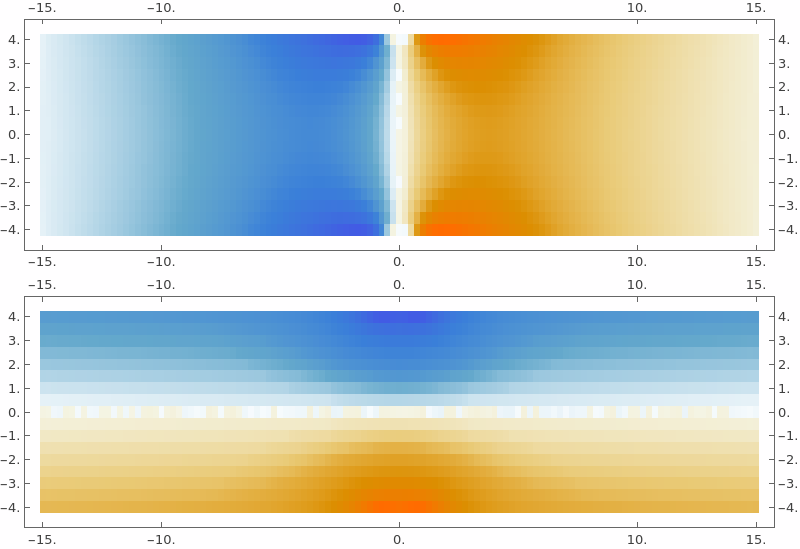

In [492]:
(* Plot the kick map data *)

{
	{MatrixPlot["xkick1" /. map // Transpose, DataRange -> {{xmin, xmax},  {zmin, zmax}}, ImageSize -> 600]},
	{MatrixPlot["ykick1" /. map // Transpose, DataRange -> {{xmin, xmax},  {zmin, zmax}}, ImageSize -> 600]}
} // Grid

-Graphics-

-Graphics-
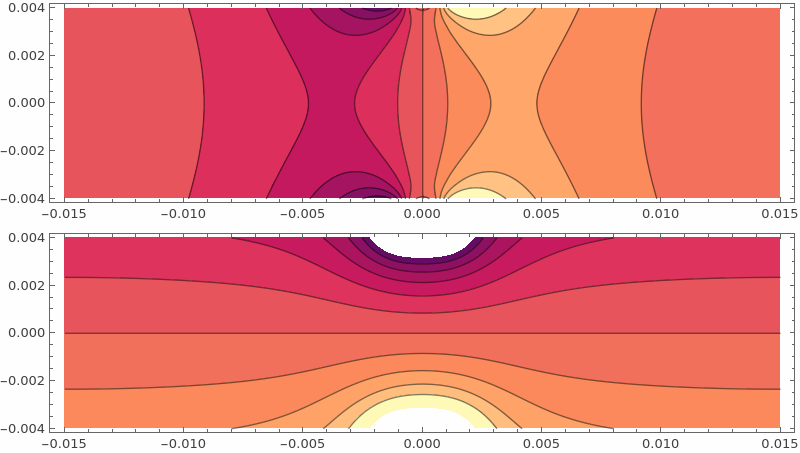

In [494]:
(* It can also be used in WM for tracking (comparison of nonlinear effects) and visualization *)
(* The following constructs interpolated tables from the given kick map *)
(* The kicks are for one ID period and are not normalized by energy, and the sizes are in meters *)

data = interpolate[map] ;

{
	{ContourPlot[data["XKick"][x, y], {x, xmin*10^-3, xmax*10^-3}, {y, zmin*10^-3, zmax*10^-3}, AspectRatio -> (zmax - zmin)/(xmax - xmin), PlotPoints -> 100, ImageSize -> 600, Contours -> 10]},
	{ContourPlot[data["YKick"][x, y], {x, xmin*10^-3, xmax*10^-3}, {y, zmin*10^-3, zmax*10^-3}, AspectRatio -> (zmax - zmin)/(xmax - xmin), PlotPoints -> 100, ImageSize -> 600, Contours -> 10]}
} // Grid

In [499]:
(* Perform tracking using one kick per ID period *)

final$nk = dkd[magnet, energy, delta, {lp, lp}, {1}, 0.0, 0.1, np, {1, 1}, "SamplesPerHarmonic" -> 32][initial] 
final$km = km[map, delta, np, {1, 1}, "Energy" -> energy][initial] 

-6                          -6
{0.000249927, 7.57294 10  , 0.000249865, -9.90115 10  }
                        -6                          -6
{0.000249927, 7.56937 10  , 0.000249865, -9.90153 10  }

In [502]:
(* Define parametric transport matrix (one kick per period) *)

ClearAll[mkm] ;
mkm[delta_, epsilon_] := Block[
	{positive, negative},
	positive = km[map, delta, np, {1, 1}, "Energy" -> energy, "Delta" -> True] /@ (+epsilon*IdentityMatrix[4]) ;
	negative = km[map, delta, np, {1, 1}, "Energy" -> energy, "Delta" -> True] /@ (-epsilon*IdentityMatrix[4]) ;
	symplectify[Transpose[(positive - negative)/(2*epsilon)]]
] ;

In [505]:
(* Compute on-energy transport matrix and corresponding exponent *)

M$KM = mkm[0.0*delta, epsilon] ;
A$KM = - S . MatrixLog[M$KM] // Re ;

In [508]:
(* Compute leading order chromatic matrix *)

positive = mkm[+delta, epsilon] ;
negative = mkm[-delta, epsilon] ;
dMddp = (positive - negative)/(2*delta) ;

B$KM = - S . MatrixExp[- S . A$KM] . dMddp ;
B$KM = 1/2 (B$KM + Transpose[B$KM]) ;

-13            -11
0.999705         -0.019521        -2.12336 10      4.4563 10

                                            -11               -13
0.0302493        0.999705         -6.7162 10       -2.22754 10

           -13             -11
-2.40365 10      4.45628 10       0.999465         0.0269634

           -11              -13
-6.71621 10      -2.42881 10      -0.0396316       0.999466
                                             -13             -11
0.999705         -0.0195326       -2.12507 10      4.45896 10

                                             -11              -13
0.0302555        0.999704         -6.71753 10      -2.22925 10

           -13             -11
-2.40568 10      4.45893 10       0.999465         0.0269798

           -11              -13
-6.71755 10      -2.43062 10      -0.0396392       0.999465
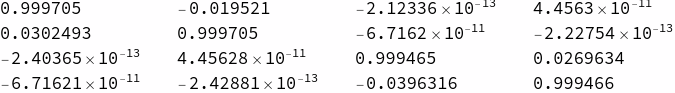
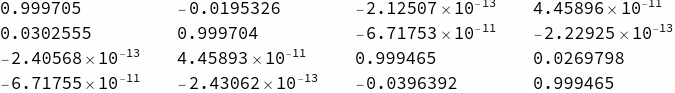

In [514]:
positive // TableForm
negative // TableForm

-0.0302751   0.           0.          0.

0.           -0.0195412   0.          0.

0.           0.           0.0396543   0.

0.           0.           0.          0.0269846
-0.0302553   0.           0.          0.

0.           -0.0195287   0.          0.

0.           0.           0.0396425   0.

0.           0.           0.          0.0269764
-0.0299495    0.           0.           0.000824342

0.            -0.0189326   0.00091243   0.

0.            0.00091243   0.039276     0.

0.000824342   0.           0.           0.0261859
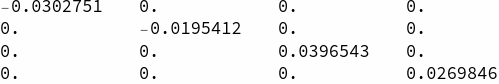
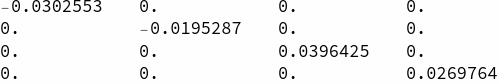
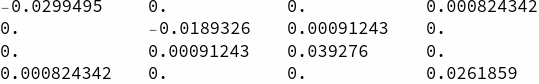

In [516]:
(* Compare on-energy transport matrix exponents *)

Chop[A$NK, 10.0^-6] // N // TableForm
Chop[A$KM, 10.0^-6] // N // TableForm
Chop[A$RK, 10.0^-6] // N // TableForm

0.0311414     0.000577805   0.           0.

0.000577805   0.0582638     0.           0.

0.            0.            -0.0381967   0.00110162

0.            0.            0.00110162   -0.0815743
0.0311198     0.000577248   0.           0.

0.000577248   0.0582277     0.           0.

0.            0.            -0.0381853   0.0011013

0.            0.            0.0011013    -0.0815511
                                       -6
0.0307692     0.000548175     5.0521 10     -0.00170198

                                                       -6
0.000548175   0.0564399       -0.00175574   -2.31261 10

         -6
5.0521 10     -0.00175574     -0.0378717    0.0010582

                         -6
-0.00170198   -2.31261 10     0.0010582     -0.079199
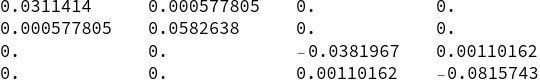
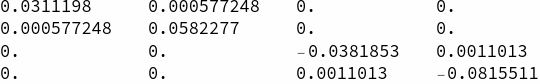
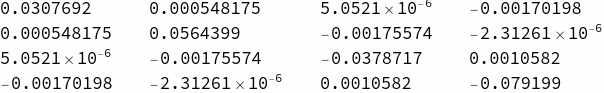

In [520]:
(* Compare leading order chromatic exponents *)

Chop[B$NK, 10.0^-6] // N // TableForm
Chop[B$KM, 10.0^-6] // N // TableForm
Chop[B$RK, 10.0^-6] // N // TableForm